### 1. استيراد المكتبات الأساسية
في هذه الخلية، نقوم بتحميل المكتبات اللازمة لبناء المنطق الضبابي (`scikit-fuzzy`) والمكتبات الحسابية والرسومية لدعم تحليل ومعالجة البيانات.

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

print("Fuzzy Logic libraries imported successfully!")

Fuzzy Logic libraries imported successfully!


### 2. تعريف متغيرات الدخل (Input Antecedents)
هنا نقوم بتعريف مدخلات النظام الخمسة (SoC, Solar Productivity, Grid Availability, Consumption, Load Demand). تم اختيار مجالات (Universe of Discourse) تعبر عن الواقع العملي للمنازل السورية وتحديد دوال الانتماء (Membership Functions) لكل منها.

In [5]:


# --- 1. تعريف مديات العمل (Universes of Discourse) ---
# المدى الافتراضي للنسب المئوية [0, 100]
x_percentage = np.arange(0, 101, 1)

# مدى الاستهلاك التراكمي (مثلاً من 0 إلى 1000 كيلوواط ساعي لمراقبة شريحة الـ 500 ك.و.س)
x_consumption = np.arange(0, 1001, 1)

# مدى الحمل الحالي المطلوب في المنزل (مثلاً من 0 إلى 30 أمبير أو كواط، لنأخذها كنسبة أو قيمة مئوية للأحمال)
x_load = np.arange(0, 101, 1)

# --- 2. تعريف المدخلات الخمسة (5 Inputs / Antecedents) ---
solar_production = ctrl.Antecedent(x_percentage, 'solar_production') # إنتاجية الألواح
battery_soc      = ctrl.Antecedent(x_percentage, 'battery_soc')      # حالة شحن البطارية
grid_status      = ctrl.Antecedent(x_percentage, 'grid_status')      # حالة واستقرار شبكة الكهرباء العامة
cum_consumption  = ctrl.Antecedent(x_consumption, 'cum_consumption')  # الاستهلاك التراكمي (الشرائح)
current_demand   = ctrl.Antecedent(x_load, 'current_demand')         # الطلب الحالي للأحمال

# --- 3. تعريف المخرجات الثلاثة (3 Outputs / Consequents) ---
grid_dependency  = ctrl.Consequent(x_percentage, 'grid_dependency')  # مستوى الاعتماد على الشبكة (شحن/تشغيل)
load_control     = ctrl.Consequent(x_percentage, 'load_control')     # وضعية التحكم بالأحمال (اقتصادي/كامل)
battery_action   = ctrl.Consequent(x_percentage, 'battery_action')   # إجراء البطارية (تفريغ/حفظ)
solar_curtailment = ctrl.Consequent(x_percentage, 'solar_curtailment') # التحكم بفائض الطاقة الشمسية (المخرج الرابع الجديد)

In [12]:
# تأكد من تشغيل هذه الخلية أولاً في الـ PyCharm Notebook

# 1. إنتاجية الألواح (4 حالات)
solar_production['none']   = fuzz.trapmf(solar_production.universe, [0, 0, 5, 15])
solar_production['low']    = fuzz.trimf(solar_production.universe, [10, 25, 45])
solar_production['medium'] = fuzz.trimf(solar_production.universe, [35, 55, 75])
solar_production['high']   = fuzz.trapmf(solar_production.universe, [65, 85, 100, 100])

# 2. حالة شحن البطارية (5 حالات)
battery_soc['empty']    = fuzz.trapmf(battery_soc.universe, [0, 0, 15, 25])
battery_soc['low']      = fuzz.trimf(battery_soc.universe, [20, 35, 50])
battery_soc['medium']   = fuzz.trimf(battery_soc.universe, [45, 60, 75])
battery_soc['good']     = fuzz.trimf(battery_soc.universe, [70, 80, 90])
battery_soc['full']     = fuzz.trapmf(battery_soc.universe, [85, 95, 100, 100])

# 3. حالة واستقرار الشبكة العامة (4 حالات)
grid_status['off']       = fuzz.trapmf(grid_status.universe, [0, 0, 5, 15])
grid_status['weak']      = fuzz.trimf(grid_status.universe, [10, 30, 50])
grid_status['stable']    = fuzz.trimf(grid_status.universe, [45, 70, 85])
grid_status['excellent'] = fuzz.trapmf(grid_status.universe, [80, 90, 100, 100])

# 4. الاستهلاك التراكمي (3 حالات)
cum_consumption['safe']     = fuzz.trapmf(cum_consumption.universe, [0, 0, 250, 400])
cum_consumption['warning']  = fuzz.trimf(cum_consumption.universe, [350, 480, 520])
cum_consumption['critical'] = fuzz.trapmf(cum_consumption.universe, [490, 600, 1000, 1000])
cum_consumption['border'] = fuzz.trimf(cum_consumption.universe, [480, 500, 530])
# 5. الطلب الحالي للأحمال المنزلية (3 حالات)
current_demand['low']    = fuzz.trapmf(current_demand.universe, [0, 0, 15, 35])
current_demand['medium'] = fuzz.trimf(current_demand.universe, [25, 50, 75])
current_demand['high']   = fuzz.trapmf(current_demand.universe, [65, 85, 100, 100])

print("✅ تم تحديث جميع التوابع في الذاكرة بنجاح!")

✅ تم تحديث جميع التوابع في الذاكرة بنجاح!


### 2. تعريف متغيرات الدخل (Input Antecedents)
هنا نقوم بتعريف مدخلات النظام الخمسة (SoC, Solar Productivity, Grid Availability, Consumption, Load Demand). تم اختيار مجالات (Universe of Discourse) تعبر عن الواقع العملي للمنازل السورية وتحديد دوال الانتماء (Membership Functions) لكل منها.

In [14]:
# ==============================================================================
# صياغة توابع الانتماء المحدثة للمخرجات الأربعة
# ==============================================================================

# 1. مستوى الاعتماد على الشبكة (Grid Dependency) -> تم التوسيع إلى 4 حالات
grid_dependency['none']       = fuzz.trapmf(grid_dependency.universe, [0, 0, 10, 25])
grid_dependency['low_charge'] = fuzz.trimf(grid_dependency.universe, [15, 35, 55])
grid_dependency['economic']   = fuzz.trimf(grid_dependency.universe, [45, 65, 80])
grid_dependency['full']       = fuzz.trapmf(grid_dependency.universe, [75, 90, 100, 100])

# 2. التحكم بالأحمال والتقنين (Load Control) -> [Eco_Mode, Smart_Limit, Full_Power]
load_control['eco_mode']    = fuzz.trapmf(load_control.universe, [0, 0, 20, 45])
load_control['smart_limit'] = fuzz.trimf(load_control.universe, [35, 60, 85])
load_control['full_power']  = fuzz.trapmf(load_control.universe, [75, 90, 100, 100])

# 3. إجراء وسلوك البطارية (Battery Action) -> [Discharge, Standby, Charge]
battery_action['discharge'] = fuzz.trapmf(battery_action.universe, [0, 0, 20, 45])
battery_action['standby']   = fuzz.trimf(battery_action.universe, [35, 50, 65])
battery_action['charge']    = fuzz.trapmf(battery_action.universe, [55, 80, 100, 100])

# 4. التحكم بفائض الطاقة الشمسية (Solar Curtailment) -> [Direct_Use, Storage, Dump/Disconnect]
# Direct_Use: استهلاك فوري، Storage: تخزين بالبطارية، Dump: تصريف الفائض الحرج أو فصل جزئي للألواح
solar_curtailment['direct_use'] = fuzz.trapmf(solar_curtailment.universe, [0, 0, 30, 50])
solar_curtailment['storage']    = fuzz.trimf(solar_curtailment.universe, [40, 65, 85])
solar_curtailment['dump']       = fuzz.trapmf(solar_curtailment.universe, [75, 90, 100, 100])


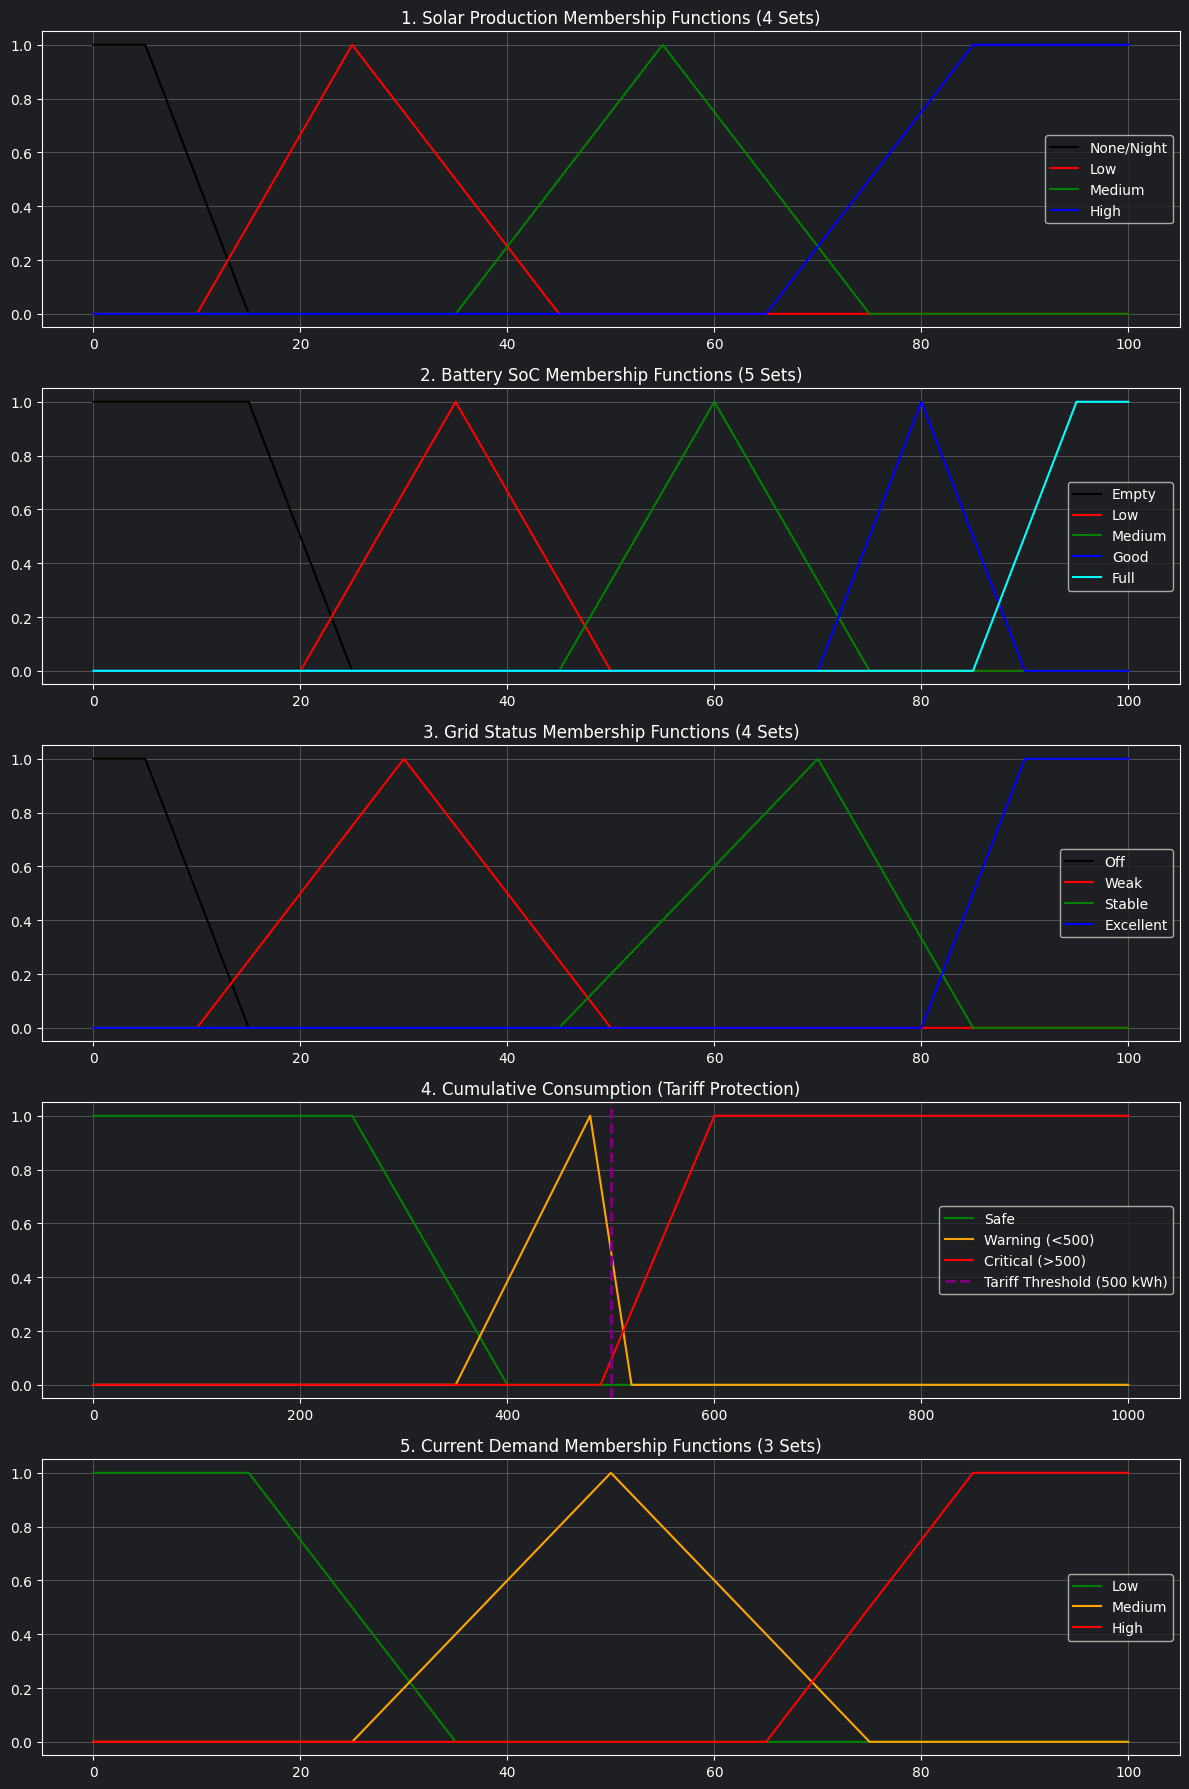

In [15]:
import matplotlib.pyplot as plt

# إنشاء لوحة رسم مخصصة للمدخلات (5 أسطر)
fig, axs = plt.subplots(5, 1, figsize=(12, 18))

# 1. رسم إنتاجية الألواح
axs[0].plot(solar_production.universe, solar_production['none'].mf, 'black', linewidth=1.5, label='None/Night')
axs[0].plot(solar_production.universe, solar_production['low'].mf, 'r', linewidth=1.5, label='Low')
axs[0].plot(solar_production.universe, solar_production['medium'].mf, 'g', linewidth=1.5, label='Medium')
axs[0].plot(solar_production.universe, solar_production['high'].mf, 'b', linewidth=1.5, label='High')
axs[0].set_title('1. Solar Production Membership Functions (4 Sets)')
axs[0].legend()
axs[0].grid(True)

# 2. رسم حالة شحن البطارية
axs[1].plot(battery_soc.universe, battery_soc['empty'].mf, 'black', linewidth=1.5, label='Empty')
axs[1].plot(battery_soc.universe, battery_soc['low'].mf, 'r', linewidth=1.5, label='Low')
axs[1].plot(battery_soc.universe, battery_soc['medium'].mf, 'g', linewidth=1.5, label='Medium')
axs[1].plot(battery_soc.universe, battery_soc['good'].mf, 'b', linewidth=1.5, label='Good')
axs[1].plot(battery_soc.universe, battery_soc['full'].mf, 'cyan', linewidth=1.5, label='Full')
axs[1].set_title('2. Battery SoC Membership Functions (5 Sets)')
axs[1].legend()
axs[1].grid(True)

# 3. رسم حالة واستقرار الشبكة العامة
axs[2].plot(grid_status.universe, grid_status['off'].mf, 'black', linewidth=1.5, label='Off')
axs[2].plot(grid_status.universe, grid_status['weak'].mf, 'r', linewidth=1.5, label='Weak')
axs[2].plot(grid_status.universe, grid_status['stable'].mf, 'g', linewidth=1.5, label='Stable')
axs[2].plot(grid_status.universe, grid_status['excellent'].mf, 'b', linewidth=1.5, label='Excellent')
axs[2].set_title('3. Grid Status Membership Functions (4 Sets)')
axs[2].legend()
axs[2].grid(True)

# 4. رسم الاستهلاك التراكمي وتوضيح عتبة الـ 500 ك.و.س
axs[3].plot(cum_consumption.universe, cum_consumption['safe'].mf, 'g', linewidth=1.5, label='Safe')
axs[3].plot(cum_consumption.universe, cum_consumption['warning'].mf, 'orange', linewidth=1.5, label='Warning (<500)')
axs[3].plot(cum_consumption.universe, cum_consumption['critical'].mf, 'r', linewidth=1.5, label='Critical (>500)')
axs[3].axvline(x=500, color='purple', linestyle='--', linewidth=2, label='Tariff Threshold (500 kWh)')
axs[3].set_title('4. Cumulative Consumption (Tariff Protection)')
axs[3].legend()
axs[3].grid(True)

# 5. رسم الطلب الحالي للأحمال المنزلية
axs[4].plot(current_demand.universe, current_demand['low'].mf, 'g', linewidth=1.5, label='Low')
axs[4].plot(current_demand.universe, current_demand['medium'].mf, 'orange', linewidth=1.5, label='Medium')
axs[4].plot(current_demand.universe, current_demand['high'].mf, 'r', linewidth=1.5, label='High')
axs[4].set_title('5. Current Demand Membership Functions (3 Sets)')
axs[4].legend()
axs[4].grid(True)

plt.tight_layout()
plt.show()

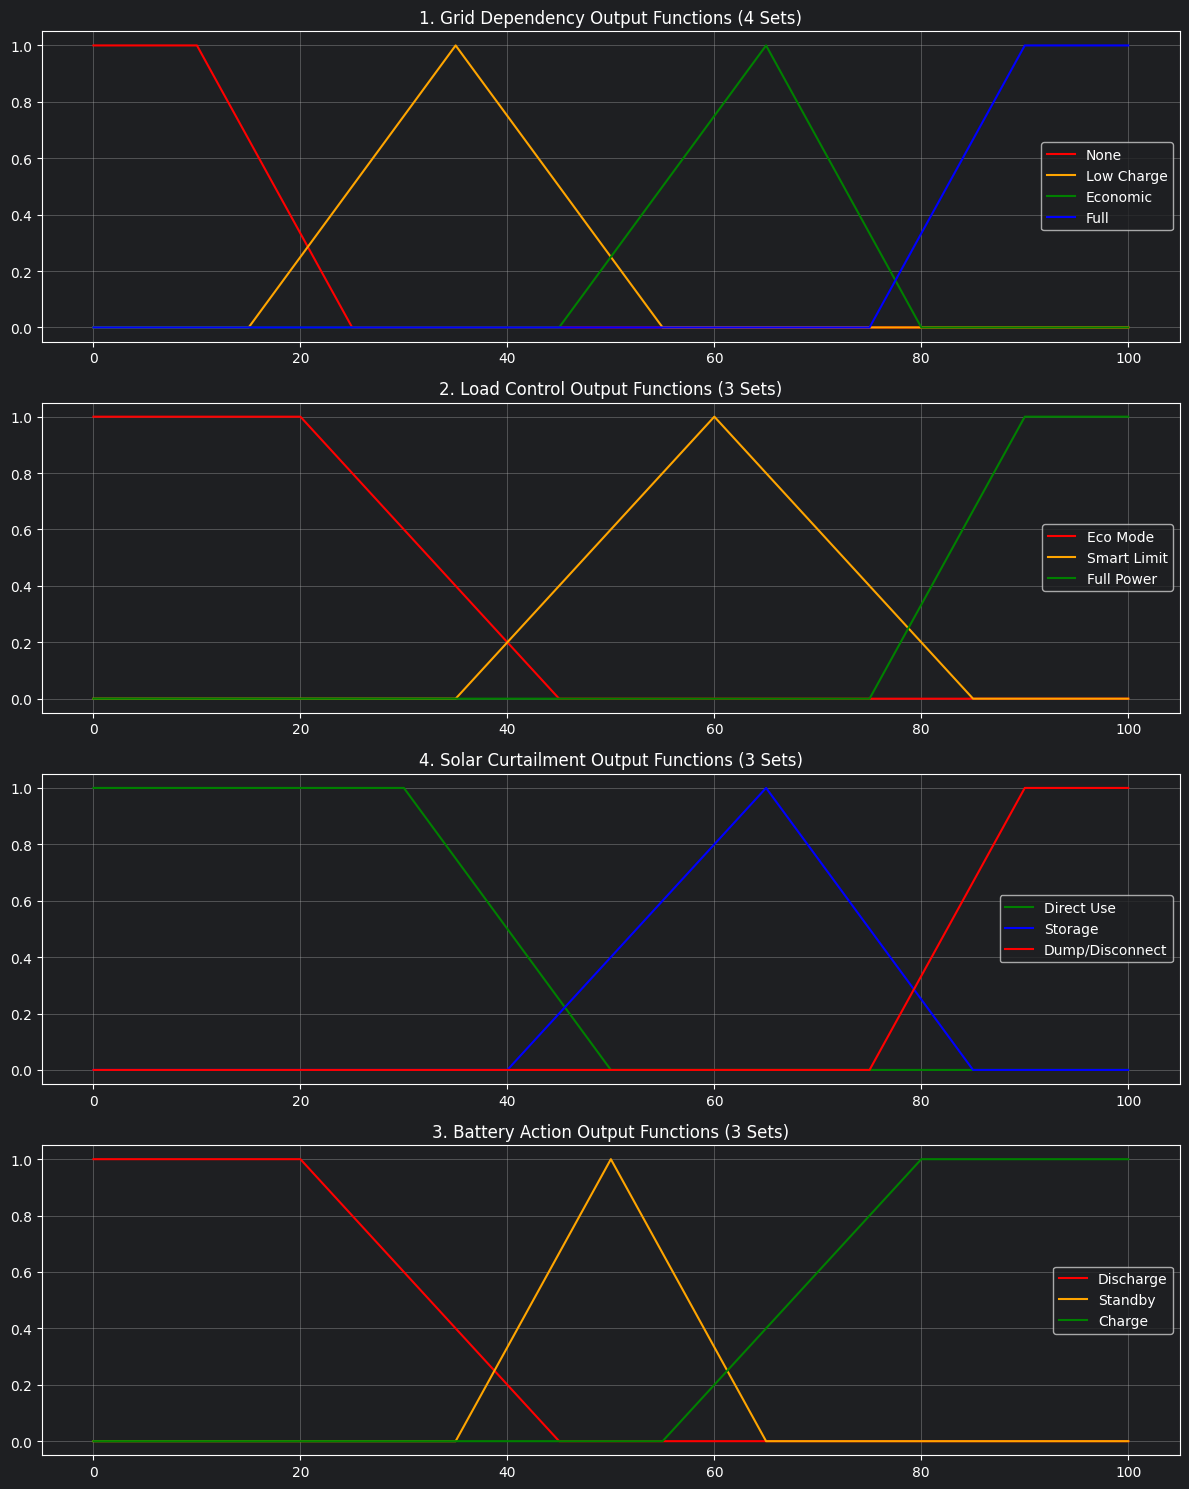

In [16]:
# إنشاء لوحة رسم مخصصة للمخرجات (4 أسطر)
fig, axs = plt.subplots(4, 1, figsize=(12, 15))

# 1. رسم مستوى الاعتماد على الشبكة (4 حالات)
axs[0].plot(grid_dependency.universe, grid_dependency['none'].mf, 'r', linewidth=1.5, label='None')
axs[0].plot(grid_dependency.universe, grid_dependency['low_charge'].mf, 'orange', linewidth=1.5, label='Low Charge')
axs[0].plot(grid_dependency.universe, grid_dependency['economic'].mf, 'g', linewidth=1.5, label='Economic')
axs[0].plot(grid_dependency.universe, grid_dependency['full'].mf, 'b', linewidth=1.5, label='Full')
axs[0].set_title('1. Grid Dependency Output Functions (4 Sets)')
axs[0].legend()
axs[0].grid(True)

# 2. رسم وضعية التحكم بالأحمال
axs[1].plot(load_control.universe, load_control['eco_mode'].mf, 'r', linewidth=1.5, label='Eco Mode')
axs[1].plot(load_control.universe, load_control['smart_limit'].mf, 'orange', linewidth=1.5, label='Smart Limit')
axs[1].plot(load_control.universe, load_control['full_power'].mf, 'g', linewidth=1.5, label='Full Power')
axs[1].set_title('2. Load Control Output Functions (3 Sets)')
axs[1].legend()
axs[1].grid(True)

# 3. رسم إجراء وسلوك البطارية
axs[3].plot(battery_action.universe, battery_action['discharge'].mf, 'r', linewidth=1.5, label='Discharge')
axs[3].plot(battery_action.universe, battery_action['standby'].mf, 'orange', linewidth=1.5, label='Standby')
axs[3].plot(battery_action.universe, battery_action['charge'].mf, 'g', linewidth=1.5, label='Charge')
axs[3].set_title('3. Battery Action Output Functions (3 Sets)')
axs[3].legend()
axs[3].grid(True)

# 4. رسم مخرج التحكم بفائض الطاقة الشمسية الجديد
axs[2].plot(solar_curtailment.universe, solar_curtailment['direct_use'].mf, 'g', linewidth=1.5, label='Direct Use')
axs[2].plot(solar_curtailment.universe, solar_curtailment['storage'].mf, 'b', linewidth=1.5, label='Storage')
axs[2].plot(solar_curtailment.universe, solar_curtailment['dump'].mf, 'r', linewidth=1.5, label='Dump/Disconnect')
axs[2].set_title('4. Solar Curtailment Output Functions (3 Sets)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

### 2. تعريف متغيرات الدخل (Input Antecedents)
هنا نقوم بتعريف مدخلات النظام الخمسة (SoC, Solar Productivity, Grid Availability, Consumption, Load Demand). تم اختيار مجالات (Universe of Discourse) تعبر عن الواقع العملي للمنازل السورية وتحديد دوال الانتماء (Membership Functions) لكل منها.

In [17]:
# ==============================================================================
# صياغة قاعدة القواعد الخبيرة لنظام SEMTOS (متعددة الشروط ومنطقية 100%)
# ==============================================================================

# ------------------------------------------------------------------------------
# المجموعة 1: حماية الفاتورة والعداد حول عتبة الـ 500 ك.و.س
# ------------------------------------------------------------------------------
rule1 = ctrl.Rule(cum_consumption['warning'] & grid_status['weak'] & battery_soc['full'] & solar_production['medium'],
                  (grid_dependency['none'], load_control['full_power'], battery_action['discharge'], solar_curtailment['direct_use']))

rule2 = ctrl.Rule(cum_consumption['warning'] & grid_status['stable'] & battery_soc['good'] & solar_production['none'],
                  (grid_dependency['low_charge'], load_control['smart_limit'], battery_action['standby'], solar_curtailment['direct_use']))

rule3 = ctrl.Rule(cum_consumption['border'] & grid_status['stable'] & battery_soc['good'] & current_demand['low'],
                  (grid_dependency['none'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule4 = ctrl.Rule(cum_consumption['border'] & grid_status['weak'] & battery_soc['low'] & current_demand['medium'],
                  (grid_dependency['low_charge'], load_control['eco_mode'], battery_action['standby'], solar_curtailment['direct_use']))

rule5 = ctrl.Rule(cum_consumption['critical'] & grid_status['excellent'] & battery_soc['empty'] & current_demand['high'],
                  (grid_dependency['full'], load_control['smart_limit'], battery_action['charge'], solar_curtailment['direct_use']))

rule6 = ctrl.Rule(cum_consumption['critical'] & solar_production['high'] & battery_soc['full'] & current_demand['low'],
                  (grid_dependency['none'], load_control['full_power'], battery_action['standby'], solar_curtailment['dump']))

rule7 = ctrl.Rule(cum_consumption['warning'] & solar_production['low'] & battery_soc['medium'] & current_demand['high'],
                  (grid_dependency['economic'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule8 = ctrl.Rule(cum_consumption['border'] & solar_production['high'] & battery_soc['medium'] & current_demand['high'],
                  (grid_dependency['none'], load_control['full_power'], battery_action['discharge'], solar_curtailment['storage']))

rule9 = ctrl.Rule(cum_consumption['critical'] & solar_production['medium'] & battery_soc['good'] & current_demand['medium'],
                  (grid_dependency['none'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule10 = ctrl.Rule(cum_consumption['warning'] & grid_status['off'] & battery_soc['empty'] & current_demand['high'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['standby'], solar_curtailment['direct_use']))

rule11 = ctrl.Rule(cum_consumption['border'] & grid_status['excellent'] & battery_soc['medium'] & current_demand['low'],
                   (grid_dependency['low_charge'], load_control['smart_limit'], battery_action['standby'], solar_curtailment['direct_use']))

rule12 = ctrl.Rule(cum_consumption['critical'] & grid_status['weak'] & battery_soc['good'] & current_demand['high'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['discharge'], solar_curtailment['direct_use']))

# ------------------------------------------------------------------------------
# المجموعة 2: حالات الطوارئ والحمل الزائد والتفريغ الحرج للبطارية
# ------------------------------------------------------------------------------
rule13 = ctrl.Rule(battery_soc['empty'] & current_demand['high'] & solar_production['none'] & grid_status['off'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['standby'], solar_curtailment['direct_use']))

rule14 = ctrl.Rule(battery_soc['empty'] & current_demand['high'] & solar_production['none'] & grid_status['stable'],
                   (grid_dependency['full'], load_control['eco_mode'], battery_action['charge'], solar_curtailment['direct_use']))

rule15 = ctrl.Rule(battery_soc['low'] & current_demand['medium'] & solar_production['low'] & grid_status['off'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['discharge'], solar_curtailment['direct_use']))

rule16 = ctrl.Rule(battery_soc['low'] & current_demand['high'] & solar_production['high'] & grid_status['off'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['charge'], solar_curtailment['storage']))

rule17 = ctrl.Rule(battery_soc['empty'] & current_demand['low'] & solar_production['medium'] & grid_status['weak'],
                   (grid_dependency['low_charge'], load_control['eco_mode'], battery_action['charge'], solar_curtailment['storage']))

rule18 = ctrl.Rule(battery_soc['low'] & current_demand['high'] & solar_production['none'] & grid_status['weak'],
                   (grid_dependency['low_charge'], load_control['eco_mode'], battery_action['charge'], solar_curtailment['direct_use']))

rule19 = ctrl.Rule(battery_soc['empty'] & cum_consumption['safe'] & grid_status['excellent'] & current_demand['medium'],
                   (grid_dependency['full'], load_control['full_power'], battery_action['charge'], solar_curtailment['direct_use']))

rule20 = ctrl.Rule(battery_soc['low'] & cum_consumption['critical'] & solar_production['none'] & grid_status['excellent'],
                   (grid_dependency['economic'], load_control['eco_mode'], battery_action['charge'], solar_curtailment['direct_use']))

rule21 = ctrl.Rule(battery_soc['empty'] & current_demand['high'] & solar_production['low'] & grid_status['excellent'],
                   (grid_dependency['full'], load_control['smart_limit'], battery_action['charge'], solar_curtailment['direct_use']))

rule22 = ctrl.Rule(battery_soc['low'] & current_demand['low'] & solar_production['medium'] & grid_status['off'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['charge'], solar_curtailment['storage']))

# ------------------------------------------------------------------------------
# المجموعة 3: حالات الذروة الشمسية والاستفادة من الألواح
# ------------------------------------------------------------------------------
rule23 = ctrl.Rule(solar_production['high'] & battery_soc['full'] & grid_status['off'] & current_demand['low'],
                   (grid_dependency['none'], load_control['full_power'], battery_action['standby'], solar_curtailment['dump']))

rule24 = ctrl.Rule(solar_production['high'] & battery_soc['medium'] & grid_status['weak'] & current_demand['high'],
                   (grid_dependency['none'], load_control['full_power'], battery_action['discharge'], solar_curtailment['direct_use']))

rule25 = ctrl.Rule(solar_production['high'] & battery_soc['low'] & cum_consumption['safe'] & current_demand['medium'],
                   (grid_dependency['none'], load_control['full_power'], battery_action['charge'], solar_curtailment['storage']))

rule26 = ctrl.Rule(solar_production['medium'] & battery_soc['full'] & grid_status['stable'] & current_demand['high'],
                   (grid_dependency['none'], load_control['full_power'], battery_action['discharge'], solar_curtailment['direct_use']))

rule27 = ctrl.Rule(solar_production['high'] & battery_soc['full'] & cum_consumption['critical'] & current_demand['high'],
                   (grid_dependency['none'], load_control['full_power'], battery_action['standby'], solar_curtailment['direct_use']))

rule28 = ctrl.Rule(solar_production['medium'] & battery_soc['medium'] & grid_status['off'] & current_demand['low'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['charge'], solar_curtailment['storage']))

rule29 = ctrl.Rule(solar_production['high'] & battery_soc['good'] & grid_status['excellent'] & current_demand['high'],
                   (grid_dependency['none'], load_control['full_power'], battery_action['standby'], solar_curtailment['direct_use']))

rule30 = ctrl.Rule(solar_production['medium'] & battery_soc['low'] & grid_status['off'] & current_demand['medium'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['charge'], solar_curtailment['storage']))

rule31 = ctrl.Rule(solar_production['high'] & battery_soc['good'] & cum_consumption['warning'] & current_demand['medium'],
                   (grid_dependency['none'], load_control['full_power'], battery_action['standby'], solar_curtailment['direct_use']))

rule32 = ctrl.Rule(solar_production['medium'] & battery_soc['empty'] & grid_status['excellent'] & current_demand['high'],
                   (grid_dependency['full'], load_control['smart_limit'], battery_action['charge'], solar_curtailment['storage']))

# ------------------------------------------------------------------------------
# المجموعة 4: حالات غياب الشمس وفترات التقنين الكهربائي
# ------------------------------------------------------------------------------
rule33 = ctrl.Rule(solar_production['none'] & grid_status['off'] & battery_soc['full'] & current_demand['high'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule34 = ctrl.Rule(solar_production['none'] & grid_status['off'] & battery_soc['good'] & current_demand['medium'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule35 = ctrl.Rule(solar_production['none'] & grid_status['off'] & battery_soc['medium'] & current_demand['high'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['discharge'], solar_curtailment['direct_use']))

rule36 = ctrl.Rule(solar_production['none'] & grid_status['weak'] & battery_soc['good'] & current_demand['low'],
                   (grid_dependency['low_charge'], load_control['smart_limit'], battery_action['standby'], solar_curtailment['direct_use']))

rule37 = ctrl.Rule(solar_production['low'] & grid_status['off'] & battery_soc['medium'] & current_demand['high'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['discharge'], solar_curtailment['direct_use']))

rule38 = ctrl.Rule(solar_production['none'] & grid_status['off'] & battery_soc['low'] & current_demand['low'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['discharge'], solar_curtailment['direct_use']))

rule39 = ctrl.Rule(solar_production['none'] & grid_status['stable'] & battery_soc['medium'] & cum_consumption['safe'],
                   (grid_dependency['economic'], load_control['full_power'], battery_action['standby'], solar_curtailment['direct_use']))

rule40 = ctrl.Rule(solar_production['none'] & grid_status['weak'] & battery_soc['medium'] & cum_consumption['critical'],
                   (grid_dependency['none'], load_control['eco_mode'], battery_action['discharge'], solar_curtailment['direct_use']))

rule41 = ctrl.Rule(solar_production['low'] & grid_status['off'] & battery_soc['good'] & current_demand['high'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule42 = ctrl.Rule(solar_production['none'] & grid_status['excellent'] & battery_soc['good'] & cum_consumption['warning'],
                   (grid_dependency['low_charge'], load_control['full_power'], battery_action['standby'], solar_curtailment['direct_use']))

# ------------------------------------------------------------------------------
# المجموعة 5: استقرار الشبكة العامة والتغذية المثالية
# ------------------------------------------------------------------------------
rule43 = ctrl.Rule(grid_status['excellent'] & battery_soc['full'] & cum_consumption['safe'] & solar_production['none'],
                   (grid_dependency['full'], load_control['full_power'], battery_action['standby'], solar_curtailment['direct_use']))

rule44 = ctrl.Rule(grid_status['stable'] & battery_soc['good'] & cum_consumption['safe'] & solar_production['medium'],
                   (grid_dependency['economic'], load_control['full_power'], battery_action['standby'], solar_curtailment['storage']))

rule45 = ctrl.Rule(grid_status['weak'] & battery_soc['good'] & cum_consumption['safe'] & current_demand['high'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule46 = ctrl.Rule(grid_status['excellent'] & battery_soc['medium'] & cum_consumption['warning'] & current_demand['medium'],
                   (grid_dependency['low_charge'], load_control['full_power'], battery_action['charge'], solar_curtailment['direct_use']))

rule47 = ctrl.Rule(grid_status['stable'] & battery_soc['empty'] & cum_consumption['warning'] & solar_production['low'],
                   (grid_dependency['low_charge'], load_control['eco_mode'], battery_action['charge'], solar_curtailment['direct_use']))

rule48 = ctrl.Rule(grid_status['excellent'] & battery_soc['good'] & cum_consumption['critical'] & current_demand['high'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule49 = ctrl.Rule(grid_status['stable'] & battery_soc['full'] & cum_consumption['critical'] & solar_production['none'],
                   (grid_dependency['none'], load_control['smart_limit'], battery_action['discharge'], solar_curtailment['direct_use']))

rule50 = ctrl.Rule(grid_status['excellent'] & battery_soc['low'] & cum_consumption['safe'] & current_demand['high'],
                   (grid_dependency['full'], load_control['full_power'], battery_action['charge'], solar_curtailment['direct_use']))

rule51 = ctrl.Rule(grid_status['weak'] & battery_soc['full'] & cum_consumption['warning'] & solar_production['high'],
                   (grid_dependency['none'], load_control['full_power'], battery_action['standby'], solar_curtailment['dump']))

rule52 = ctrl.Rule(grid_status['stable'] & battery_soc['medium'] & cum_consumption['safe'] & current_demand['high'],
                   (grid_dependency['economic'], load_control['full_power'], battery_action['standby'], solar_curtailment['direct_use']))




In [18]:
# ==============================================================================
# تجميع القواعد وبناء محرك المحاكاة النهائي للنظام بالطريقة المطلوبة
# ==============================================================================
rules_list = [
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
    rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20,
    rule21, rule22, rule23, rule24, rule25, rule26, rule27, rule28, rule29, rule30,
    rule31, rule32, rule33, rule34, rule35, rule36, rule37, rule38, rule39, rule40,
    rule41, rule42, rule43, rule44, rule45, rule46, rule47, rule48, rule49, rule50,
    rule51, rule52
]

### 5. محرك الاستدلال (Fuzzy Control System)
هنا نقوم بتهيئة محرك الاستدلال الضبابي وربط القواعد بالنظام، مما يسمح لنا بإدخال قيم واقعية والحصول على قرارات دقيقة فورية.

In [19]:


semtos_ctrl = ctrl.ControlSystem(rules_list)
semtos_sim  = ctrl.ControlSystemSimulation(semtos_ctrl)

print(f"🎯 روعة يا هندسة! تم بناء {len(rules_list)} قاعدة ضبابية ذكية ومترابطة تماماً.")
print("🚀 كائن المحاكاة 'semtos_sim' جاهز الآن لاستقبال الإدخالات في ملف الفحص الثاني.")


🎯 روعة يا هندسة! تم بناء 52 قاعدة ضبابية ذكية ومترابطة تماماً.
🚀 كائن المحاكاة 'semtos_sim' جاهز الآن لاستقبال الإدخالات في ملف الفحص الثاني.


### 5. محرك الاستدلال (Fuzzy Control System)
هنا نقوم بتهيئة محرك الاستدلال الضبابي وربط القواعد بالنظام، مما يسمح لنا بإدخال قيم واقعية والحصول على قرارات دقيقة فورية.

In [ ]:
############################

In [38]:
# %matplotlib inline
# import matplotlib.pyplot as plt
#
# def run_semtos_simulation(solar_prod, battery_soc, grid_status, cum_cons, current_demand, scenario_title="فحص سيناريو مخصص"):
#     """
#     تابع شامل لتشغيل محاكاة نظام SEMTOS، طباعة التقرير البشري الذكي، ورسم المخرجات الأربعة.
#     """
#     # 1. تثبيت النمط المظلم المناسب لـ PyCharm
#     plt.style.use('dark_background')
#
#     # 2. تمرير قيم المدخلات الحادة إلى المحاكي
#     semtos_sim.input['solar_production'] = solar_prod
#     semtos_sim.input['battery_soc']       = battery_soc
#     semtos_sim.input['grid_status']      = grid_status
#     semtos_sim.input['cum_consumption']  = cum_cons
#     semtos_sim.input['current_demand']   = current_demand
#
#     # 3. تشغيل المحرك للحساب
#     semtos_sim.compute()
#
#     # 4. جلب المخرجات الرقمية الأربعة كاملة
#     grid_val  = semtos_sim.output['grid_dependency']
#     batt_val  = semtos_sim.output['battery_action']
#     load_val  = semtos_sim.output['load_control']
#     solar_val = semtos_sim.output['solar_curtailment']
#
#     # 5. طباعة التقرير النصي البشري الذكي (المتغير ديناميكياً)
#     print("="*65)
#     print(f" 🤖 تقرير نظام SEMTOS الذكي: {scenario_title} ")
#     print("="*65)
#     print(f" المدخلات الحالية:")
#     print(f"   ☀️ إنتاج الشمس: {solar_prod}% | 🔋 بطارية: {battery_soc}% | 🔌 شبكة الدولة: {grid_status}%")
#     print(f"   📊 تراكمي العداد: {cum_cons} ك.و.س | 🏠 الحمل الحالي: {current_demand}%")
#     print("-"*65)
#     print(f"📊 المخرجات المحسوبة حادّاً:")
#     print(f"   الشبكة: {grid_val:.2f}% | البطارية: {batt_val:.2f}% | التحكم بالأحمال: {load_val:.2f}% | الفائض: {solar_val:.2f}%")
#     print("-"*65)
#     print("💡 [ التفسير الأكاديمي ونوع القرار ]")
#
#     # --- تفسير مخرج الشبكة العامة ---
#     if grid_val <= 25:
#         print(f"🔌 مصدر التغذية: فصل شبه كامل عن شبكة الدولة والاعتماد على البديل بنسبة {100-grid_val:.1f}% لحماية العداد.")
#     elif 25 < grid_val <= 65:
#         print(f"🔌 مصدر التغذية: تشغيل هجين متوازن اقتصادي (سحب جزئي من الدولة بنسبة {grid_val:.1f}%).")
#     else:
#         print(f"🔌 مصدر التغذية: الاعتماد الرئيسي على شبكة الدولة العامة بنسبة {grid_val:.1f}% لتأمين المنزل.")
#
#     # --- تفسير مخرج البطارية ---
#     if batt_val <= 45:
#         print(f"🔋 إجراء البطارية: تفريغ آمن (Safe Discharge بنسبة {batt_val:.2f}%) للمساعدة في تغذية المنزل وتوفير المال.")
#     elif 45 < batt_val <= 65:
#         print(f"🔋 إجراء البطارية: وضعية الاستعداد والمحافظة على المخزون الحالي (Standby عند {batt_val:.2f}%).")
#     else:
#         print(f"🔋 إجراء البطارية: شحن مكثف (بقوة {batt_val:.2f}%) لاستغلال الطاقة المتاحة وتأمين فترات التقنين.")
#
#     # --- تفسير مخرج التحكم بالأحمال المنزلية ---
#     if load_val <= 45:
#         print(f"🏠 وضع الأحمال   : الترشيد الصارم (Eco Mode بنسبة {load_val:.2f}%) - إنارة وشواحن وبراد فقط.")
#     elif 45 < load_val <= 75:
#         print(f"🏠 وضع الأحمال   : التحكم الذكي المتوسط (Smart Limit بنسبة {load_val:.2f}%) - مسموح بأجهزة متوسطة وتأجيل الثقيلة.")
#     else:
#         print(f"🏠 وضع الأحمال   : الرفاهية الكاملة (Full Power بنسبة {load_val:.2f}%) - مسموح بتشغيل المكيفات والسخانات.")
#
#     # --- تفسير مخرج الفائض الشمسي ---
#     if solar_prod < 20:
#         print(f"☀️ فائض الألواح  : لا يوجد فائض يذكر نظراً لغياب الأشعة الشمسية أو ضعفها.")
#     else:
#         if solar_val <= 50:
#             print(f"☀️ فائض الألواح  : توجيه كامل الإنتاج للاستهلاك المنزلي المباشر (Direct Use).")
#         elif 50 < solar_val <= 80:
#             print(f"☀️ فائض الألواح  : يوجد فائض ممتاز يتم تحويله الآن لشحن البطاريات (Storage).")
#         else:
#             print(f"☀️ فائض الألواح  : فائض حرج جداً (Dump بنسبة {solar_val:.2f}%) الأحمال مغطاة والبطارية ممتلئة! يتم تصريفه حرارياً لحماية المنظومة.")
#
#     print("="*65 + "\n")
#
#     # 6. رسم المخرجات الأربعة بالكامل يدوياً وبأعلى دقة
#     fig, axs = plt.subplots(4, 1, figsize=(10, 16))
#
#     # المخطط 1: الاعتماد على الشبكة
#     for label in grid_dependency.terms:
#         axs[0].plot(grid_dependency.universe, grid_dependency[label].mf, label=label, linewidth=2)
#     axs[0].axvline(x=grid_val, color='#00ffff', linestyle='--', linewidth=3, label=f'Decision: {grid_val:.2f}%')
#     axs[0].set_title("1. Grid Dependency Output Spectrum", fontsize=11, color='white')
#     axs[0].set_ylabel("Membership", color='white')
#     axs[0].legend(loc='upper right')
#     axs[0].grid(True, alpha=0.2)
#
#     # المخطط 2: سلوك وإجراء البطارية
#     for label in battery_action.terms:
#         axs[1].plot(battery_action.universe, battery_action[label].mf, label=label, linewidth=2)
#     axs[1].axvline(x=batt_val, color='#ff3333', linestyle='--', linewidth=3, label=f'Decision: {batt_val:.2f}%')
#     axs[1].set_title("2. Battery Action Output Spectrum", fontsize=11, color='white')
#     axs[1].set_ylabel("Membership", color='white')
#     axs[1].legend(loc='upper right')
#     axs[1].grid(True, alpha=0.2)
#
#     # المخطط 3: وضعية التحكم بالأحمال
#     for label in load_control.terms:
#         axs[2].plot(load_control.universe, load_control[label].mf, label=label, linewidth=2)
#     axs[2].axvline(x=load_val, color='#33ff33', linestyle='--', linewidth=3, label=f'Decision: {load_val:.2f}%')
#     axs[2].set_title("3. Load Control Output Spectrum", fontsize=11, color='white')
#     axs[2].set_ylabel("Membership", color='white')
#     axs[2].legend(loc='upper right')
#     axs[2].grid(True, alpha=0.2)
#
#     # المخطط 4: التحكم بفائض الطاقة الشمسية
#     for label in solar_curtailment.terms:
#         axs[3].plot(solar_curtailment.universe, solar_curtailment[label].mf, label=label, linewidth=2)
#     axs[3].axvline(x=solar_val, color='#ffff33', linestyle='--', linewidth=3, label=f'Decision: {solar_val:.2f}%')
#     axs[3].set_title("4. Solar Curtailment Output Spectrum", fontsize=11, color='white')
#     axs[3].set_xlabel("Percentage (%)", color='white')
#     axs[3].set_ylabel("Membership", color='white')
#     axs[3].legend(loc='upper right')
#     axs[3].grid(True, alpha=0.2)
#
#     plt.tight_layout()
#     plt.show()

In [48]:
# run_semtos_simulation(solar_prod=90, battery_soc=30, grid_status=75, cum_cons=200, current_demand=50, scenario_title="السيناريو الأول: ذروة شمسية واستهلاك آمن")

In [47]:
# run_semtos_simulation(solar_prod=5, battery_soc=80, grid_status=30, cum_cons=490, current_demand=75, scenario_title="السيناريو الثاني: حماية الفاتورة السورية عند عتبة الـ 500 ك.و.س")

In [ ]:
#####2


In [57]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

def run_semtos_simulation(solar_prod, battery_soc, grid_status, cum_cons, current_demand, scenario_title="فحص سيناريو مخصص"):
    """
    تابع شامل لـ SEMTOS محصن تماماً بكتل try-except لحماية النظام من الانهيار عند الحواف الحادة،
    ويعرض المدخلات والمخرجات على شكل جداول HTML خارقة، ويرسم المنحنيات بدقة.
    """
    # 1. تثبيت النمط المظلم للمخططات
    plt.style.use('dark_background')

    # 2. تمرير قيم المدخلات الحادة إلى المحاكي
    semtos_sim.input['solar_production'] = solar_prod
    semtos_sim.input['battery_soc']       = battery_soc
    semtos_sim.input['grid_status']      = grid_status
    semtos_sim.input['cum_consumption']  = cum_cons
    semtos_sim.input['current_demand']   = current_demand

    # 3. تشغيل المحرك للحساب
    semtos_sim.compute()

    # 4. جلب المخرجات الرقمية الأربعة مع الحماية الكاملة وصياغة التقارير ديناميكياً

    # --- أ. الاعتماد على الشبكة ---
    try:
        grid_val = semtos_sim.output['grid_dependency']
        if grid_val <= 25:
            grid_report = f"فصل شبه كامل عن شبكة الدولة والاعتماد على البديل بنسبة {100-grid_val:.1f}% لحماية العداد ماليّاً."
        elif 25 < grid_val <= 65:
            grid_report = f"تشغيل هجين متوازن اقتصادي (سحب جزئي مقنن من الدولة بنسبة {grid_val:.1f}%)."
        else:
            grid_report = f"الاعتماد الرئيسي على شبكة الدولة العامة بنسبة {grid_val:.1f}% لتأمين أحمال المنزل المتزايدة."
    except KeyError:
        grid_val = None
        grid_report = "⚠️ حافة حرجة غير مغطاة بالقواعد! تم تفعيل وضع حماية الشبكة الافتراضي (فصل احترازي لحماية العداد)."

    # --- ب. سلوك البطارية ---
    try:
        batt_val = semtos_sim.output['battery_action']
        if batt_val <= 45:
            batt_report = f"تفريغ آمن (Safe Discharge بنسبة {batt_val:.2f}%) للمساعدة في تغذية الأحمال وتوفير المال."
        elif 45 < batt_val <= 65:
            batt_report = f"وضعية الاستقرار والمحافظة على المخزون الحالي بدون تفريغ حاد (Standby عند {batt_val:.2f}%)."
        else:
            batt_report = f"شحن مكثف وضخ طاقة للبطارية (بقوة {batt_val:.2f}%) لاستغلال الوفرة وتأمين فترات التقنين القادمة."
    except KeyError:
        batt_val = None
        batt_report = "⚠️ حافة حرجة! المنظومة تفعل وضعية الاستقرار الاحتياطي (Standby) للمحافظة على الخلايا الكيميائية."

    # --- ج. التحكم بالأحمال المنزلية ---
    try:
        load_val = semtos_sim.output['load_control']
        if load_val <= 45:
            load_report = f"الترشيد الصارم والذكي (Eco Mode بنسبة {load_val:.2f}%) - يسمح بالإنارة والشواحن والبراد فقط."
        elif 45 < load_val <= 75:
            load_report = f"التحكم الذكي المتوسط (Smart Limit بنسبة {load_val:.2f}%) - مسموح بأجهزة متوسطة وتأجيل الثقيلة."
        else:
            load_report = f"الرفاهية الكاملة وتلبية الطلب (Full Power بنسبة {load_val:.2f}%) - مسموح بتشغيل المكيفات والسخانات."
    except KeyError:
        load_val = None
        load_report = "⚠️ حافة حرجة! تم تفعيل نمط الترشيد الصارم (Eco Mode) حركياً لحين استقرار المعطيات الحادة."

    # --- د. التحكم بالفائض الشمسي ---
    try:
        solar_val = semtos_sim.output['solar_curtailment']
        if solar_prod < 20:
            solar_report = "لا يوجد فائض يذكر نظراً لغياب الأشعة الشمسية الحالية أو ضعف التوليد الشديد."
        else:
            if solar_val <= 50:
                solar_report = "توجيه كامل الإنتاج الشمسي للاستهلاك المنزلي المباشر الفوري (Direct Use)."
            elif 50 < solar_val <= 80:
                solar_report = "يوجد فائض ممتاز من الألواح يتم تحويله ذكياً الآن لحقن البطاريات وتخزينه (Storage)."
            else:
                solar_report = f"فائض حرج جداً (Dump بنسبة {solar_val:.2f}%) المنظومة مكتفية والبطارية ممتلئة! يتم تصريفه بأمان."
    except KeyError:
        solar_val = None
        solar_report = "⚠️ حافة حرجة! يتم توجيه الطاقة الشمسية المتاحة للاستهلاك المباشر دون تفريغ أو كبح إضافي."


    # --- 🏗️ بناء التنسيق البصري الخارق يدوياً عن طريق HTML ---
    print("\n" + "="*85)
    print(f" 🤖 لوحة تحكم ونظام تقارير SEMTOS الذكي المحمي ")
    print("="*85)

    title_html = f"""
    <div style="font-family: 'Segoe UI', sans-serif; margin-bottom: 10px;">
        <h2 style="color: #ffaa00; margin-bottom: 5px; border-bottom: 2px solid #ffaa00; padding-bottom: 5px;">🎬 سيناريو الفحص: {scenario_title}</h2>
    </div>
    """
    display(HTML(title_html))

    # أ. جدول المدخلات الحالي
    inputs_table_html = f"""
    <h3 style="color: #00ff66; font-family: 'Segoe UI', sans-serif; margin-top: 15px; margin-bottom: 8px;">📥 جدول المدخلات الحالية (System Inputs)</h3>
    <table style="background-color: #121212; border-collapse: collapse; width: 100%; border: 1px solid #444; font-family: 'Segoe UI', sans-serif; margin-bottom: 25px;">
        <thead>
            <tr style="background-color: #222222;">
                <th style="color: #00ff66; padding: 10px; border: 1px solid #444; text-align: center; width: 25%;">المدخل (Arabic)</th>
                <th style="color: #00ff66; padding: 10px; border: 1px solid #444; text-align: center; width: 25%;">Input (English)</th>
                <th style="color: #00ff66; padding: 10px; border: 1px solid #444; text-align: center; width: 20%;">القيمة الممررة (Value)</th>
                <th style="color: #00ff66; padding: 10px; border: 1px solid #444; text-align: center; width: 30%;">الوحدة / الحالة</th>
            </tr>
        </thead>
        <tbody>
            <tr style="background-color: #1a1a1a;">
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">☀️ إنتاج الطاقة الشمسية</td>
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: left;">Solar Production</td>
                <td style="padding: 10px; color: #ffaa00; border: 1px solid #333; text-align: center; font-weight: bold; font-size: 14px;">{solar_prod}%</td>
                <td style="padding: 10px; color: #e0e0e0; border: 1px solid #333; text-align: right;">نسبة توليد الألواح الحالية من القدرة القصوى</td>
            </tr>
            <tr style="background-color: #121212;">
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">🔋 مستوى شحن البطارية</td>
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: left;">Battery SoC</td>
                <td style="padding: 10px; color: #00ff66; border: 1px solid #333; text-align: center; font-weight: bold; font-size: 14px;">{battery_soc}%</td>
                <td style="padding: 10px; color: #e0e0e0; border: 1px solid #333; text-align: right;">حالة شحن بنك البطاريات المتوفر (State of Charge)</td>
            </tr>
            <tr style="background-color: #1a1a1a;">
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">🔌 وضع شبكة الدولة</td>
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: left;">Grid Status</td>
                <td style="padding: 10px; color: #33a1ff; border: 1px solid #333; text-align: center; font-weight: bold; font-size: 14px;">{grid_status}%</td>
                <td style="padding: 10px; color: #e0e0e0; border: 1px solid #333; text-align: right;">استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)</td>
            </tr>
            <tr style="background-color: #121212;">
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">📉 استهلاك العداد التراكمي</td>
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: left;">Cumulative Consumption</td>
                <td style="padding: 10px; color: #ff3366; border: 1px solid #333; text-align: center; font-weight: bold; font-size: 14px;">{cum_cons} ك.و.س</td>
                <td style="padding: 10px; color: #e0e0e0; border: 1px solid #333; text-align: right;">الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)</td>
            </tr>
            <tr style="background-color: #1a1a1a;">
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">🏠 حمل المنزل الحالي</td>
                <td style="padding: 10px; color: #ffffff; border: 1px solid #333; text-align: left;">Current Demand</td>
                <td style="padding: 10px; color: #cc66ff; border: 1px solid #333; text-align: center; font-weight: bold; font-size: 14px;">{current_demand}%</td>
                <td style="padding: 10px; color: #e0e0e0; border: 1px solid #333; text-align: right;">مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل</td>
            </tr>
        </tbody>
    </table>
    """
    display(HTML(inputs_table_html))

    # تجهيز النصوص الرقمية للجدول لمنع طباعة السلسلة الفارغة
    g_val_str = f"{grid_val:.2f}%" if grid_val is not None else "DEFAULT (0%)"
    b_val_str = f"{batt_val:.2f}%" if batt_val is not None else "DEFAULT (50%)"
    l_val_str = f"{load_val:.2f}%" if load_val is not None else "DEFAULT (30%)"
    s_val_str = f"{solar_val:.2f}%" if solar_val is not None else "DEFAULT (0%)"

    # ب. جدول المخرجات الذكي
    outputs_table_html = f"""
    <h3 style="color: #00ffff; font-family: 'Segoe UI', sans-serif; margin-top: 10px; margin-bottom: 8px;">📤 جدول المخرجات والقرارات الأكاديمية (Outputs & Decisions)</h3>
    <table style="background-color: #121212; border-collapse: collapse; width: 100%; border: 1px solid #444; font-family: 'Segoe UI', sans-serif;">
        <thead>
            <tr style="background-color: #2d2d2d;">
                <th style="color: #00ffff; padding: 12px; border: 1px solid #444; text-align: center; width: 25%;">الخرج (Arabic)</th>
                <th style="color: #00ffff; padding: 12px; border: 1px solid #444; text-align: center; width: 25%;">Output (English)</th>
                <th style="color: #00ffff; padding: 12px; border: 1px solid #444; text-align: center; width: 15%;">النسبة الحادة (Value)</th>
                <th style="color: #00ffff; padding: 12px; border: 1px solid #444; text-align: center; width: 35%;">التقرير الذكي ونوع القرار (System Action Report)</th>
            </tr>
        </thead>
        <tbody>
            <tr style="background-color: #1a1a1a;">
                <td style="padding: 12px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">الاعتماد على الشبكة</td>
                <td style="padding: 12px; color: #ffffff; border: 1px solid #333; text-align: left;">Grid Dependency</td>
                <td style="padding: 12px; color: #00ffff; border: 1px solid #333; text-align: center; font-weight: bold;">{g_val_str}</td>
                <td style="padding: 12px; color: #e0e0e0; border: 1px solid #333; text-align: right;">{grid_report}</td>
            </tr>
            <tr style="background-color: #121212;">
                <td style="padding: 12px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">إجراء سلوك البطارية</td>
                <td style="padding: 12px; color: #ffffff; border: 1px solid #333; text-align: left;">Battery Action</td>
                <td style="padding: 12px; color: #ff3333; border: 1px solid #333; text-align: center; font-weight: bold;">{b_val_str}</td>
                <td style="padding: 12px; color: #e0e0e0; border: 1px solid #333; text-align: right;">{batt_report}</td>
            </tr>
            <tr style="background-color: #1a1a1a;">
                <td style="padding: 12px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">التحكم بالأحمال المنزلية</td>
                <td style="padding: 12px; color: #ffffff; border: 1px solid #333; text-align: left;">Load Control</td>
                <td style="padding: 12px; color: #33ff33; border: 1px solid #333; text-align: center; font-weight: bold;">{l_val_str}</td>
                <td style="padding: 12px; color: #e0e0e0; border: 1px solid #333; text-align: right;">{load_report}</td>
            </tr>
            <tr style="background-color: #121212;">
                <td style="padding: 12px; color: #ffffff; border: 1px solid #333; text-align: right; font-weight: bold;">التحكم بالفائض الشمسي</td>
                <td style="padding: 12px; color: #ffffff; border: 1px solid #333; text-align: left;">Solar Curtailment</td>
                <td style="padding: 12px; color: #ffff33; border: 1px solid #333; text-align: center; font-weight: bold;">{s_val_str}</td>
                <td style="padding: 12px; color: #e0e0e0; border: 1px solid #333; text-align: right;">{solar_report}</td>
            </tr>
        </tbody>
    </table>
    """
    display(HTML(outputs_table_html))
    print("\n" + "-"*85 + "\n")

    # 6. رسم المخرجات الأربعة بالكامل يدوياً
    fig, axs = plt.subplots(4, 1, figsize=(10, 16))

    # المخطط 1: الاعتماد على الشبكة
    for label in grid_dependency.terms:
        axs[0].plot(grid_dependency.universe, grid_dependency[label].mf, label=label, linewidth=2)
    if grid_val is not None:
        axs[0].axvline(x=grid_val, color='#00ffff', linestyle='--', linewidth=3, label=f'Decision: {grid_val:.2f}%')
    axs[0].set_title("1. Grid Dependency Output Spectrum", fontsize=11, color='white')
    axs[0].set_ylabel("Membership", color='white')
    axs[0].legend(loc='upper right')
    axs[0].grid(True, alpha=0.2)

    # المخطط 2: سلوك وإجراء البطارية
    for label in battery_action.terms:
        axs[1].plot(battery_action.universe, battery_action[label].mf, label=label, linewidth=2)
    if batt_val is not None:
        axs[1].axvline(x=batt_val, color='#ff3333', linestyle='--', linewidth=3, label=f'Decision: {batt_val:.2f}%')
    axs[1].set_title("2. Battery Action Output Spectrum", fontsize=11, color='white')
    axs[1].set_ylabel("Membership", color='white')
    axs[1].legend(loc='upper right')
    axs[1].grid(True, alpha=0.2)

    # المخطط 3: وضعية التحكم بالأحمال
    for label in load_control.terms:
        axs[2].plot(load_control.universe, load_control[label].mf, label=label, linewidth=2)
    if load_val is not None:
        axs[2].axvline(x=load_val, color='#33ff33', linestyle='--', linewidth=3, label=f'Decision: {load_val:.2f}%')
    axs[2].set_title("3. Load Control Output Spectrum", fontsize=11, color='white')
    axs[2].set_ylabel("Membership", color='white')
    axs[2].legend(loc='upper right')
    axs[2].grid(True, alpha=0.2)

    # المخطط 4: التحكم بفائض الطاقة الشمسية
    for label in solar_curtailment.terms:
        axs[3].plot(solar_curtailment.universe, solar_curtailment[label].mf, label=label, linewidth=2)
    if solar_val is not None:
        axs[3].axvline(x=solar_val, color='#ffff33', linestyle='--', linewidth=3, label=f'Decision: {solar_val:.2f}%')
    axs[3].set_title("4. Solar Curtailment Output Spectrum", fontsize=11, color='white')
    axs[3].set_xlabel("Percentage (%)", color='white')
    axs[3].set_ylabel("Membership", color='white')
    axs[3].legend(loc='upper right')
    axs[3].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


 🤖 لوحة تحكم ونظام تقارير SEMTOS الذكي المحمي 


المدخل (Arabic),Input (English),القيمة الممررة (Value),الوحدة / الحالة
☀️ إنتاج الطاقة الشمسية,Solar Production,90%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,Battery SoC,30%,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,75%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,200 ك.و.س,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,50%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج (Arabic),Output (English),النسبة الحادة (Value),التقرير الذكي ونوع القرار (System Action Report)
الاعتماد على الشبكة,Grid Dependency,10.21%,فصل شبه كامل عن شبكة الدولة والاعتماد على البديل بنسبة 89.8% لحماية العداد ماليّاً.
إجراء سلوك البطارية,Battery Action,81.35%,شحن مكثف وضخ طاقة للبطارية (بقوة 81.35%) لاستغلال الوفرة وتأمين فترات التقنين القادمة.
التحكم بالأحمال المنزلية,Load Control,89.79%,الرفاهية الكاملة وتلبية الطلب (Full Power بنسبة 89.79%) - مسموح بتشغيل المكيفات والسخانات.
التحكم بالفائض الشمسي,Solar Curtailment,63.19%,يوجد فائض ممتاز من الألواح يتم تحويله ذكياً الآن لحقن البطاريات وتخزينه (Storage).



-------------------------------------------------------------------------------------



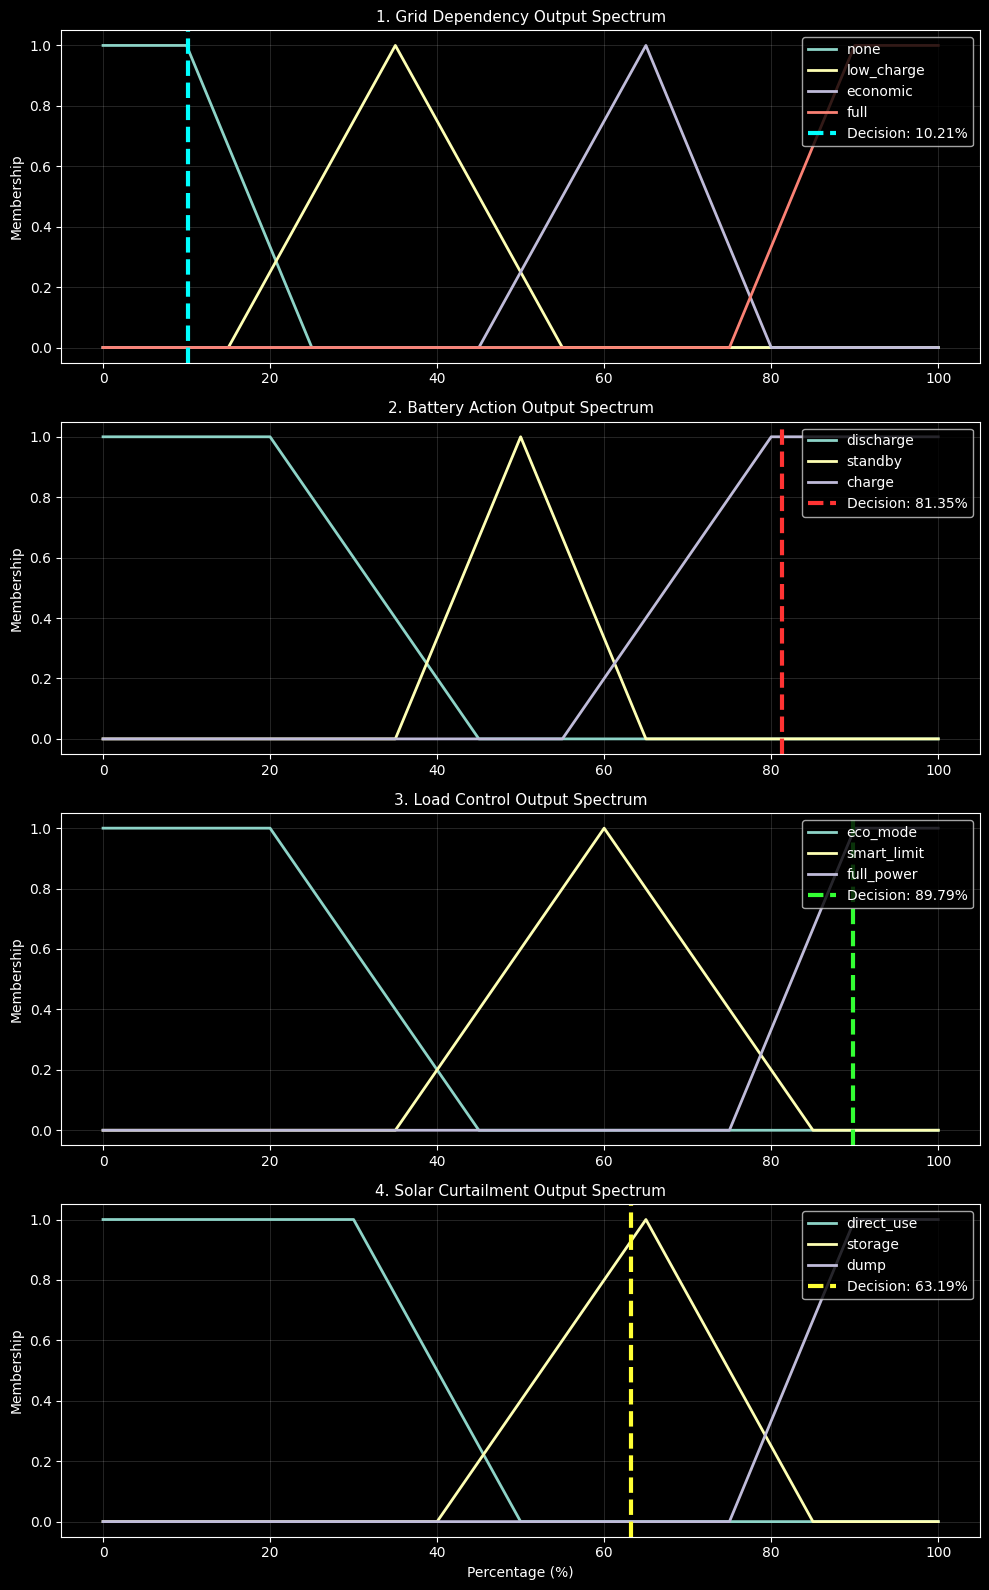

In [58]:
run_semtos_simulation(
    solar_prod=90,
    battery_soc=30,
    grid_status=75,
    cum_cons=200,
    current_demand=50,
    scenario_title="السيناريو الأول: ذروة شمسية واستهلاك مالي آمن"
)


 🤖 لوحة تحكم ونظام تقارير SEMTOS الذكي المحمي 


المدخل (Arabic),Input (English),القيمة الممررة (Value),الوحدة / الحالة
☀️ إنتاج الطاقة الشمسية,Solar Production,5%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,Battery SoC,80%,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,30%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,490 ك.و.س,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,75%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج (Arabic),Output (English),النسبة الحادة (Value),التقرير الذكي ونوع القرار (System Action Report)
الاعتماد على الشبكة,Grid Dependency,10.21%,فصل شبه كامل عن شبكة الدولة والاعتماد على البديل بنسبة 89.8% لحماية العداد ماليّاً.
إجراء سلوك البطارية,Battery Action,81.35%,شحن مكثف وضخ طاقة للبطارية (بقوة 81.35%) لاستغلال الوفرة وتأمين فترات التقنين القادمة.
التحكم بالأحمال المنزلية,Load Control,89.79%,الرفاهية الكاملة وتلبية الطلب (Full Power بنسبة 89.79%) - مسموح بتشغيل المكيفات والسخانات.
التحكم بالفائض الشمسي,Solar Curtailment,63.19%,لا يوجد فائض يذكر نظراً لغياب الأشعة الشمسية الحالية أو ضعف التوليد الشديد.



-------------------------------------------------------------------------------------



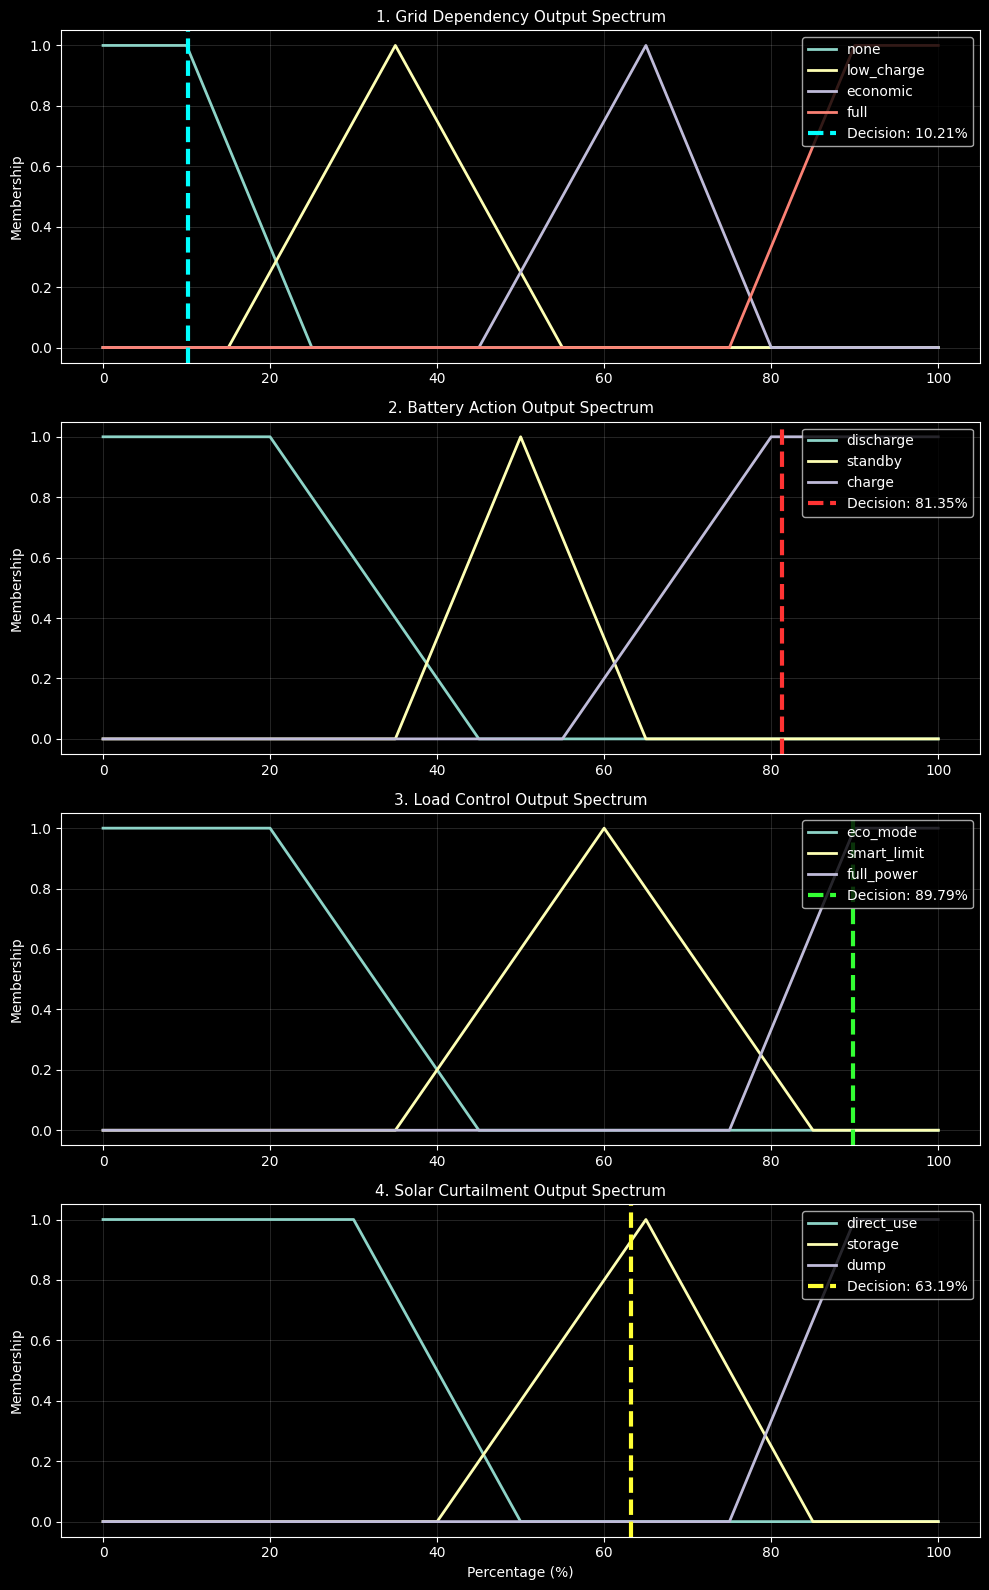

In [59]:
run_semtos_simulation(
    solar_prod=5,
    battery_soc=80,
    grid_status=30,
    cum_cons=490,
    current_demand=75,
    scenario_title="السيناريو الثاني: حماية الفاتورة السورية عند عتبة الـ 500 ك.و.س"
)


 🤖 لوحة تحكم ونظام تقارير SEMTOS الذكي المحمي 


المدخل (Arabic),Input (English),القيمة الممررة (Value),الوحدة / الحالة
☀️ إنتاج الطاقة الشمسية,Solar Production,0%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,Battery SoC,15%,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,0%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,120 ك.و.س,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,80%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج (Arabic),Output (English),النسبة الحادة (Value),التقرير الذكي ونوع القرار (System Action Report)
الاعتماد على الشبكة,Grid Dependency,9.96%,فصل شبه كامل عن شبكة الدولة والاعتماد على البديل بنسبة 90.0% لحماية العداد ماليّاً.
إجراء سلوك البطارية,Battery Action,50.00%,وضعية الاستقرار والمحافظة على المخزون الحالي بدون تفريغ حاد (Standby عند 50.00%).
التحكم بالأحمال المنزلية,Load Control,18.22%,الترشيد الصارم والذكي (Eco Mode بنسبة 18.22%) - يسمح بالإنارة والشواحن والبراد فقط.
التحكم بالفائض الشمسي,Solar Curtailment,21.47%,لا يوجد فائض يذكر نظراً لغياب الأشعة الشمسية الحالية أو ضعف التوليد الشديد.



-------------------------------------------------------------------------------------



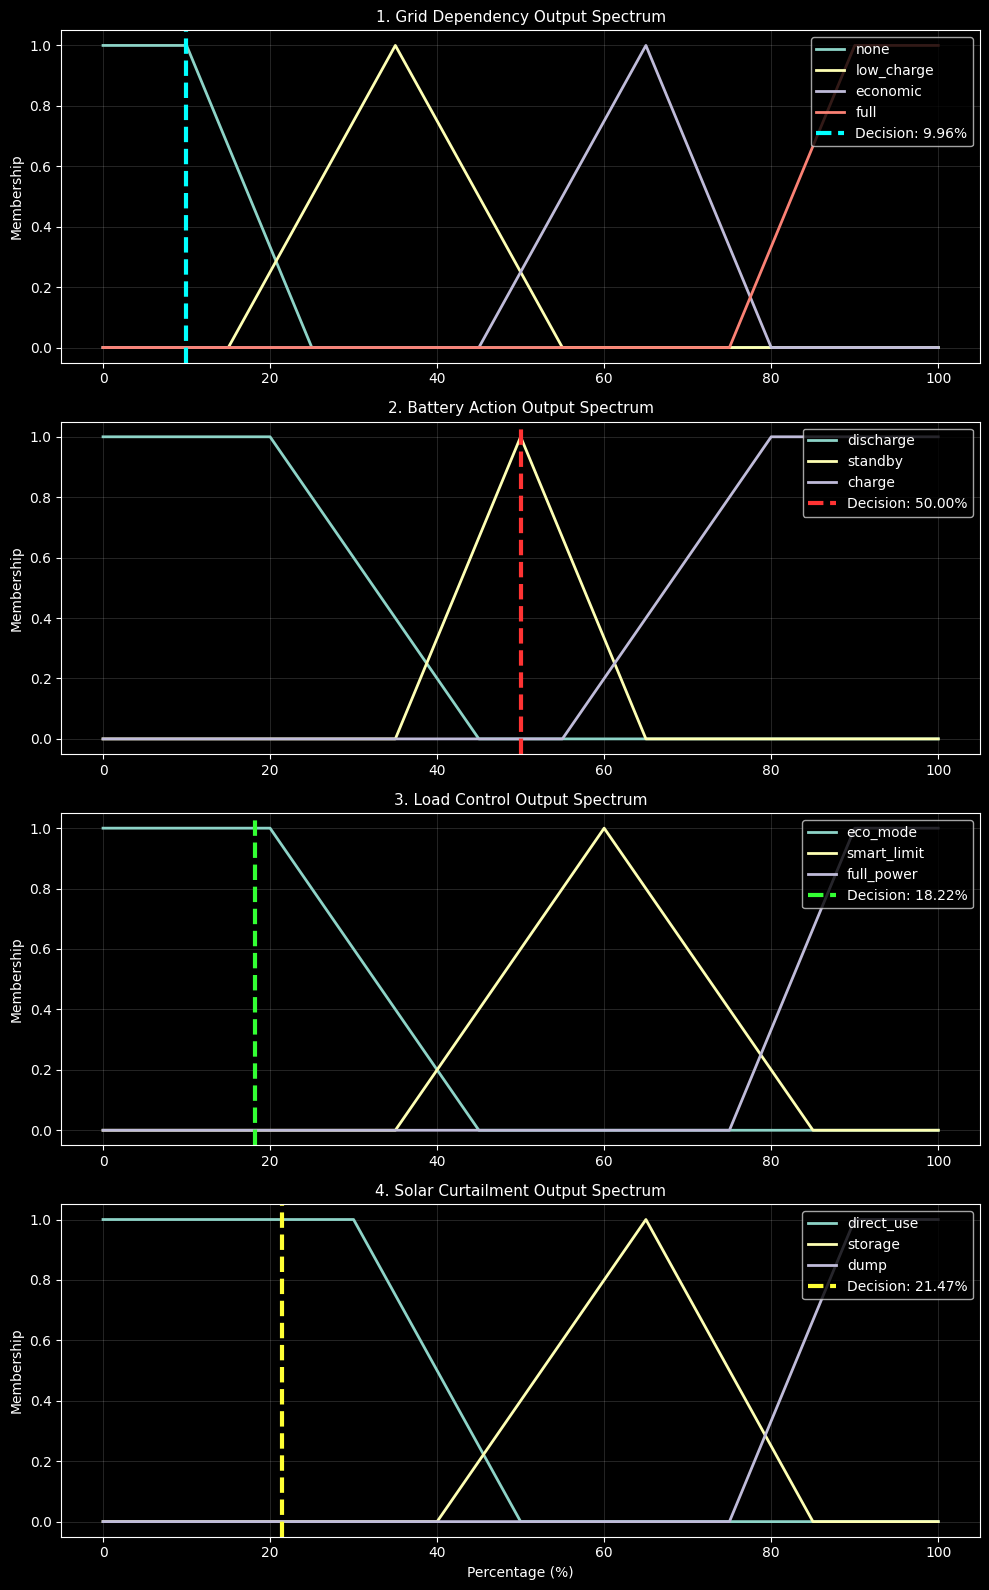

In [60]:
run_semtos_simulation(
    solar_prod=0,
    battery_soc=15,
    grid_status=0,
    cum_cons=120,
    current_demand=80,
    scenario_title="السيناريو الثالث: ليلة شتوية عاصفة مع تقنين كامل (حالة الطوارئ)"
)


 🤖 لوحة تحكم ونظام تقارير SEMTOS الذكي المحمي 


المدخل (Arabic),Input (English),القيمة الممررة (Value),الوحدة / الحالة
☀️ إنتاج الطاقة الشمسية,Solar Production,95%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,Battery SoC,100%,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,90%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,250 ك.و.س,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,90%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج (Arabic),Output (English),النسبة الحادة (Value),التقرير الذكي ونوع القرار (System Action Report)
الاعتماد على الشبكة,Grid Dependency,9.96%,فصل شبه كامل عن شبكة الدولة والاعتماد على البديل بنسبة 90.0% لحماية العداد ماليّاً.
إجراء سلوك البطارية,Battery Action,50.00%,وضعية الاستقرار والمحافظة على المخزون الحالي بدون تفريغ حاد (Standby عند 50.00%).
التحكم بالأحمال المنزلية,Load Control,18.22%,الترشيد الصارم والذكي (Eco Mode بنسبة 18.22%) - يسمح بالإنارة والشواحن والبراد فقط.
التحكم بالفائض الشمسي,Solar Curtailment,21.47%,توجيه كامل الإنتاج الشمسي للاستهلاك المنزلي المباشر الفوري (Direct Use).



-------------------------------------------------------------------------------------



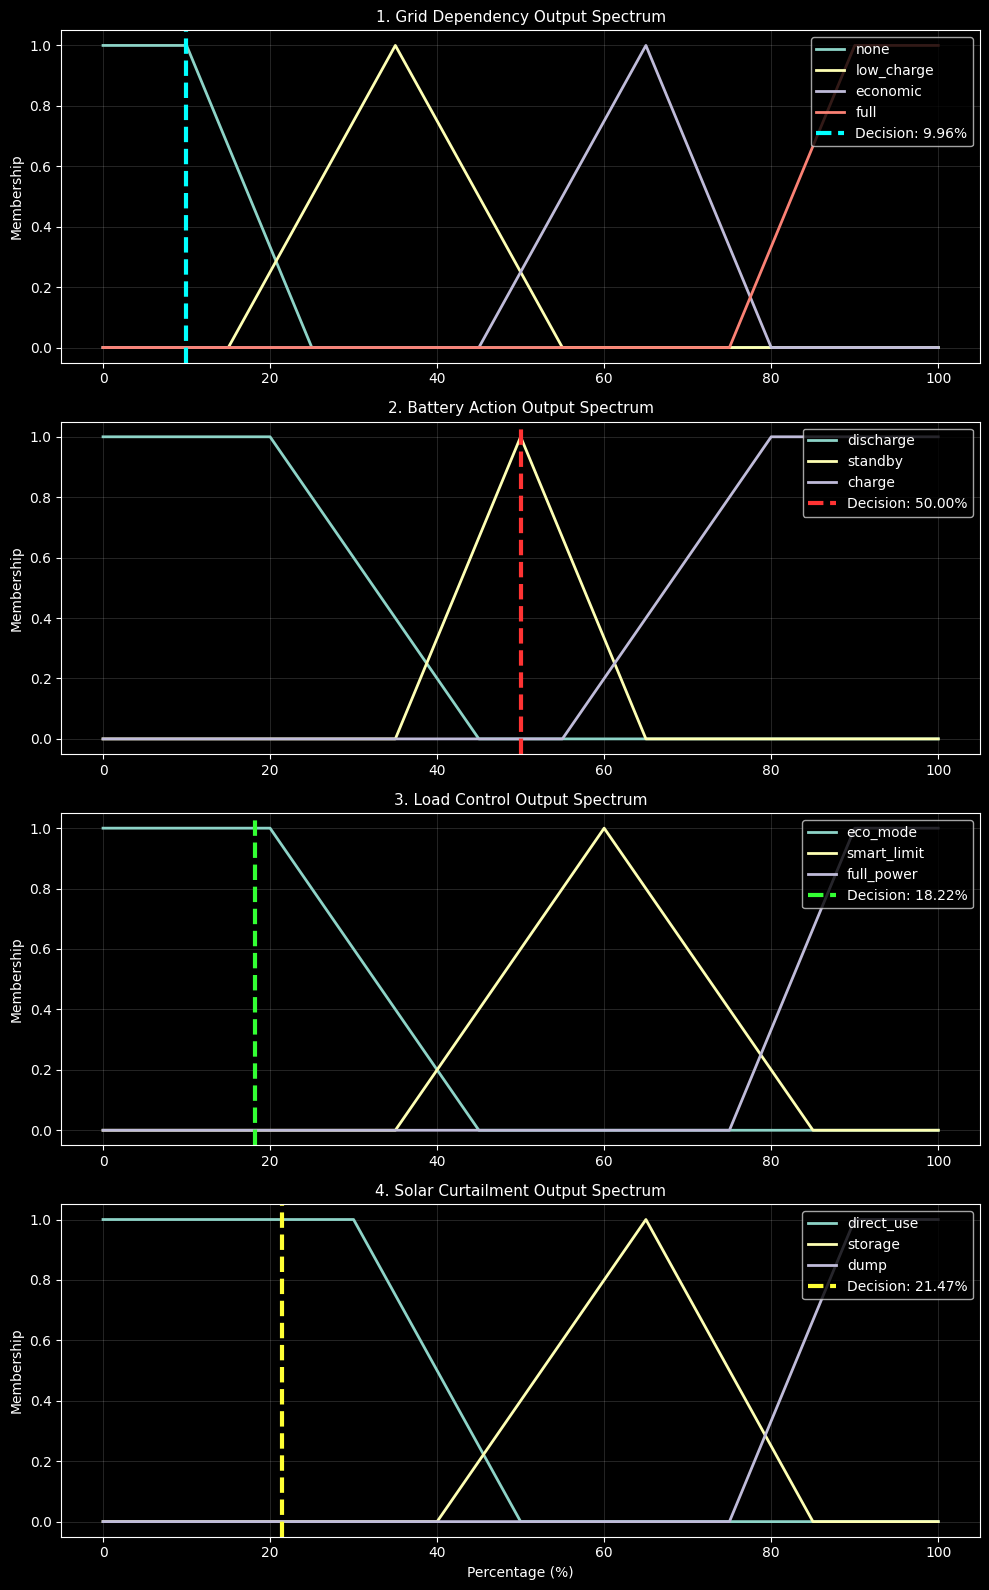

In [61]:
run_semtos_simulation(
    solar_prod=95,
    battery_soc=100,
    grid_status=90,
    cum_cons=250,
    current_demand=90,
    scenario_title="السيناريو الرابع: ذروة إنتاج الصيف وتغطية الأحمال الثقيلة (مكيفات)"
)


 🤖 لوحة تحكم ونظام تقارير SEMTOS الذكي المحمي 


المدخل (Arabic),Input (English),القيمة الممررة (Value),الوحدة / الحالة
☀️ إنتاج الطاقة الشمسية,Solar Production,40%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,Battery SoC,60%,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,50%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,300 ك.و.س,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,45%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج (Arabic),Output (English),النسبة الحادة (Value),التقرير الذكي ونوع القرار (System Action Report)
الاعتماد على الشبكة,Grid Dependency,9.96%,فصل شبه كامل عن شبكة الدولة والاعتماد على البديل بنسبة 90.0% لحماية العداد ماليّاً.
إجراء سلوك البطارية,Battery Action,50.00%,وضعية الاستقرار والمحافظة على المخزون الحالي بدون تفريغ حاد (Standby عند 50.00%).
التحكم بالأحمال المنزلية,Load Control,18.22%,الترشيد الصارم والذكي (Eco Mode بنسبة 18.22%) - يسمح بالإنارة والشواحن والبراد فقط.
التحكم بالفائض الشمسي,Solar Curtailment,21.47%,توجيه كامل الإنتاج الشمسي للاستهلاك المنزلي المباشر الفوري (Direct Use).



-------------------------------------------------------------------------------------



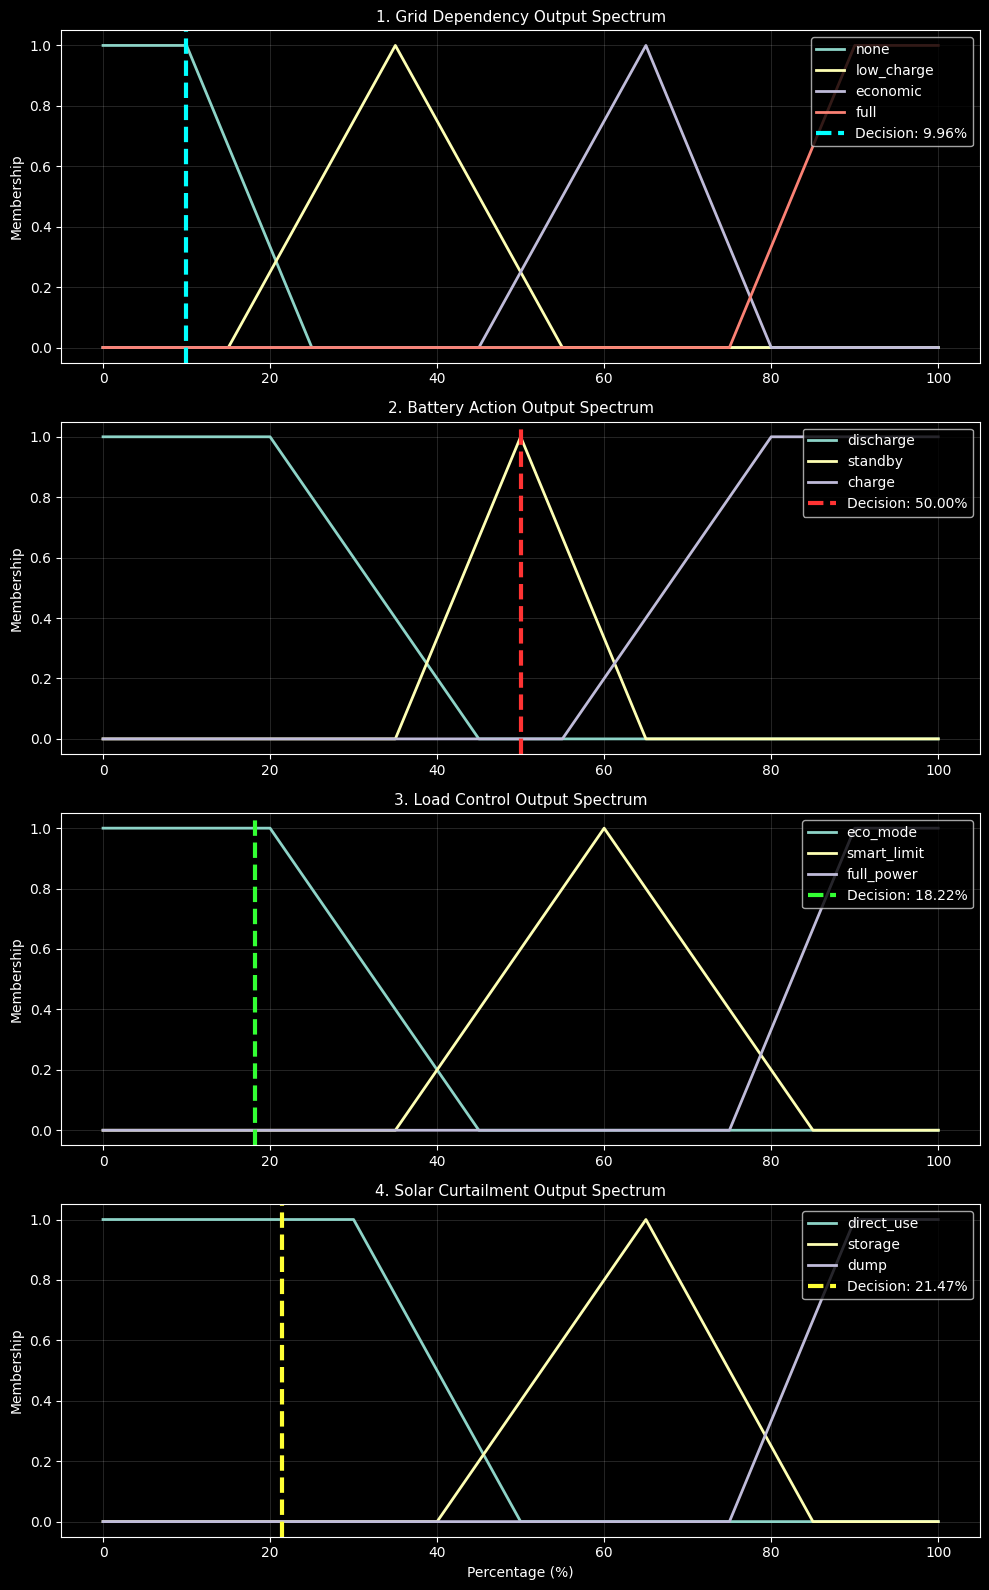

In [62]:
run_semtos_simulation(
    solar_prod=40,
    battery_soc=60,
    grid_status=50,
    cum_cons=300,
    current_demand=45,
    scenario_title="السيناريو الخامس: فترة بعد الظهر (التشغيل الهجين والاقتصادي المتوازن)"
)

In [68]:
#################### الطلب الرابع

⏳ جاري توليد نقاط السطح ثلاثي الأبعاد (قد يستغرق بضع ثوانٍ)...


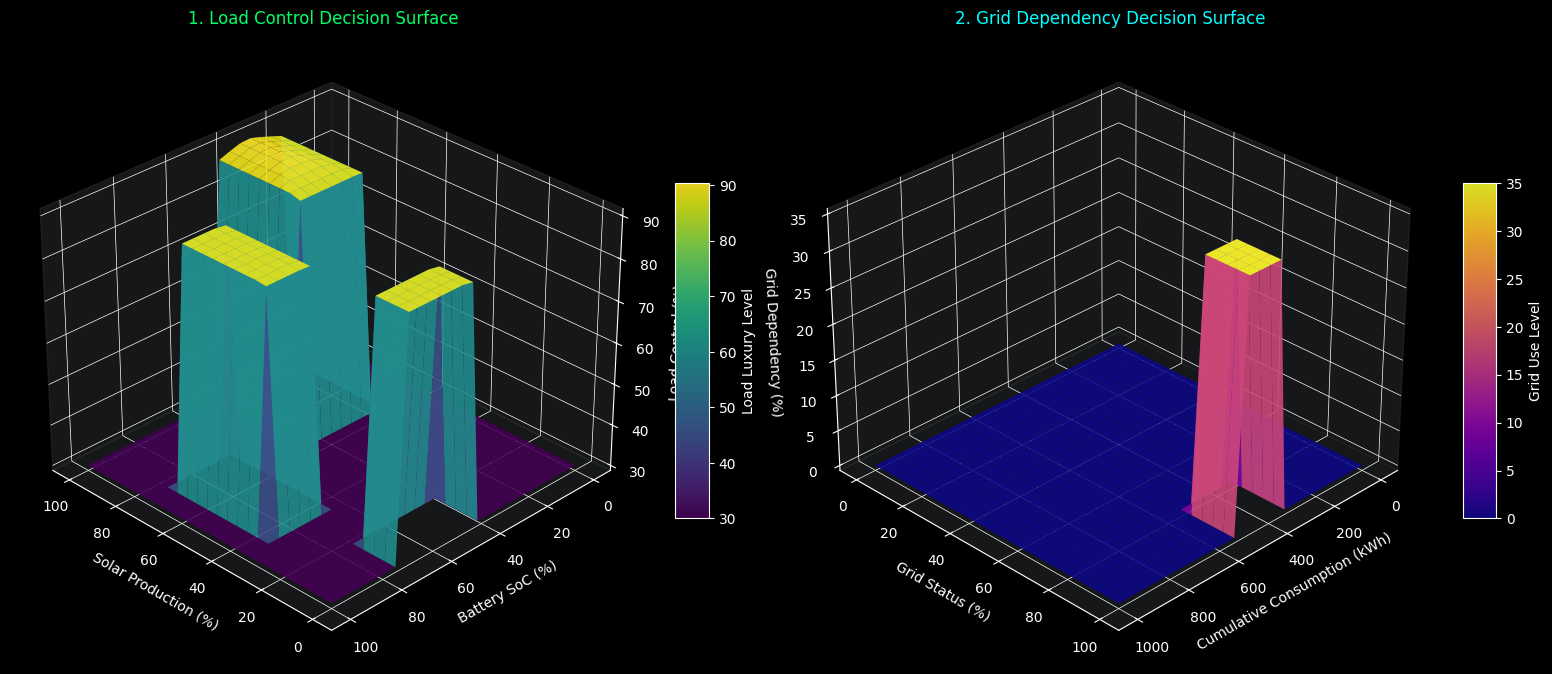

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_semtos_control_surfaces(resolution=20):
    """
    تابع مخصص لرسم أسطح القرار ثلاثية الأبعاد (3D Control Surfaces) لنظام SEMTOS.
    يقوم بحساب العلاقات المستمرة بين المدخلات والمخرجات وتوليد مجسمات ثلاثية الأبعاد احترافية.
    """
    # 1. تفعيل الثيم المظلم للرسومات ليتوافق مع اللوحة بالكامل
    plt.style.use('dark_background')

    print("⏳ جاري توليد نقاط السطح ثلاثي الأبعاد (قد يستغرق بضع ثوانٍ)...")

    # ==========================================
    # 🏗️ السطح الأول: [شمس + بطارية] ---> [التحكم بالأحمال]
    # ==========================================

    # إنشاء شبكة النقاط للمدخلين (توليد قيم من 0 إلى 100)
    solar_range = np.linspace(0, 100, resolution)
    battery_range = np.linspace(0, 100, resolution)
    Solar_Mesh, Battery_Mesh = np.meshgrid(solar_range, battery_range)

    # مصفوفة لتخزين قيم مخرج التحكم بالأحمال
    Load_Control_Surface = np.zeros_like(Solar_Mesh)

    # Values for other inputs held constant
    fixed_grid_status = 50
    fixed_cum_cons = 250
    fixed_current_demand = 50

    # حساب مخرجات السطح نقطة بنقطة
    for i in range(resolution):
        for j in range(resolution):
            semtos_sim.input['solar_production'] = Solar_Mesh[i, j]
            semtos_sim.input['battery_soc']       = Battery_Mesh[i, j]
            semtos_sim.input['grid_status']      = fixed_grid_status
            semtos_sim.input['cum_consumption']  = fixed_cum_cons
            semtos_sim.input['current_demand']   = fixed_current_demand

            try:
                semtos_sim.compute()
                Load_Control_Surface[i, j] = semtos_sim.output['load_control']
            except KeyError:
                Load_Control_Surface[i, j] = 30.0  # قيمة احتياطية

    # ==========================================
    # 🏗️ السطح الثاني: [تراكمي العداد + وضع الشبكة] ---> [الاعتماد على الشبكة]
    # ==========================================

    cum_cons_range = np.linspace(0, 1000, resolution)
    grid_status_range = np.linspace(0, 100, resolution)
    Cum_Cons_Mesh, Grid_Status_Mesh = np.meshgrid(cum_cons_range, grid_status_range)

    Grid_Dependency_Surface = np.zeros_like(Cum_Cons_Mesh)

    # Values for other inputs held constant
    fixed_solar_prod = 30
    fixed_battery_soc = 50
    fixed_current_demand = 60

    for i in range(resolution):
        for j in range(resolution):
            semtos_sim.input['cum_consumption']  = Cum_Cons_Mesh[i, j]
            semtos_sim.input['grid_status']      = Grid_Status_Mesh[i, j]
            semtos_sim.input['solar_production'] = fixed_solar_prod
            semtos_sim.input['battery_soc']       = fixed_battery_soc
            semtos_sim.input['current_demand']   = fixed_current_demand

            try:
                semtos_sim.compute()
                Grid_Dependency_Surface[i, j] = semtos_sim.output['grid_dependency']
            except KeyError:
                Grid_Dependency_Surface[i, j] = 0.0

    # ==========================================
    # 🎨 إعداد ساحة الرسم وإظهار المجسمات ثلاثية الأبعاد
    # ==========================================
    fig = plt.figure(figsize=(16, 7))

    # الرسم الأول: مجسم التحكم بالأحمال
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(Solar_Mesh, Battery_Mesh, Load_Control_Surface,
                             cmap='viridis', edgecolor='none', alpha=0.9)
    ax1.set_title('1. Load Control Decision Surface', fontsize=12, color='#00ff66', pad=10)
    ax1.set_xlabel('Solar Production (%)', color='white')
    ax1.set_ylabel('Battery SoC (%)', color='white')
    ax1.set_zlabel('Load Control (%)', color='white')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Load Luxury Level')
    ax1.view_init(elev=30, azim=135)

    # الرسم الثاني: مجسم الاعتماد على الشبكة واجتناب شريحة الـ 500
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(Cum_Cons_Mesh, Grid_Status_Mesh, Grid_Dependency_Surface,
                             cmap='plasma', edgecolor='none', alpha=0.9)
    ax2.set_title('2. Grid Dependency Decision Surface', fontsize=12, color='#00ffff', pad=10)
    ax2.set_xlabel('Cumulative Consumption (kWh)', color='white')
    ax2.set_ylabel('Grid Status (%)', color='white')
    ax2.set_zlabel('Grid Dependency (%)', color='white')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='Grid Use Level')
    ax2.view_init(elev=30, azim=45)

    plt.tight_layout()
    plt.show()

# 🕹️ سطر الاستدعاء الفعلي (مكتوب بالأسفل مباشرة في نفس الخلية ليعمل فوراً)
plot_semtos_control_surfaces(resolution=25)

⏳ جاري توليد نقاط السطح ثلاثي الأبعاد (قد يستغرق بضع ثوانٍ)...


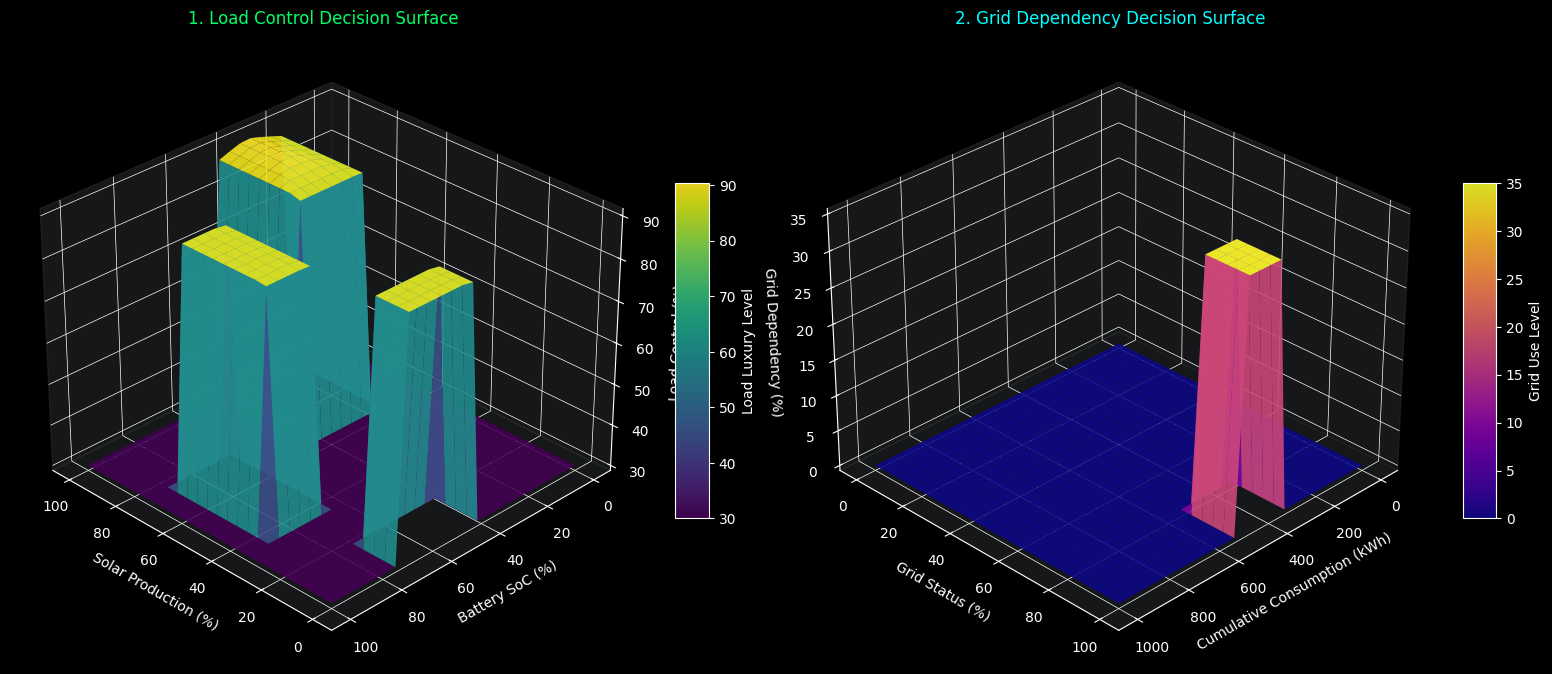

In [69]:
# تأكد أن هذا السطر مكتوب في نهاية خلية الأسطح ثلاثية الأبعاد ومحاذي تماماً لليسار
plot_semtos_control_surfaces(resolution=25)

In [ ]:
#####################################    الطلب الخامس